**Overall accuracy (all categories)**
Two-bar accuracy (prompt 1 vs 2) with 95% CI.


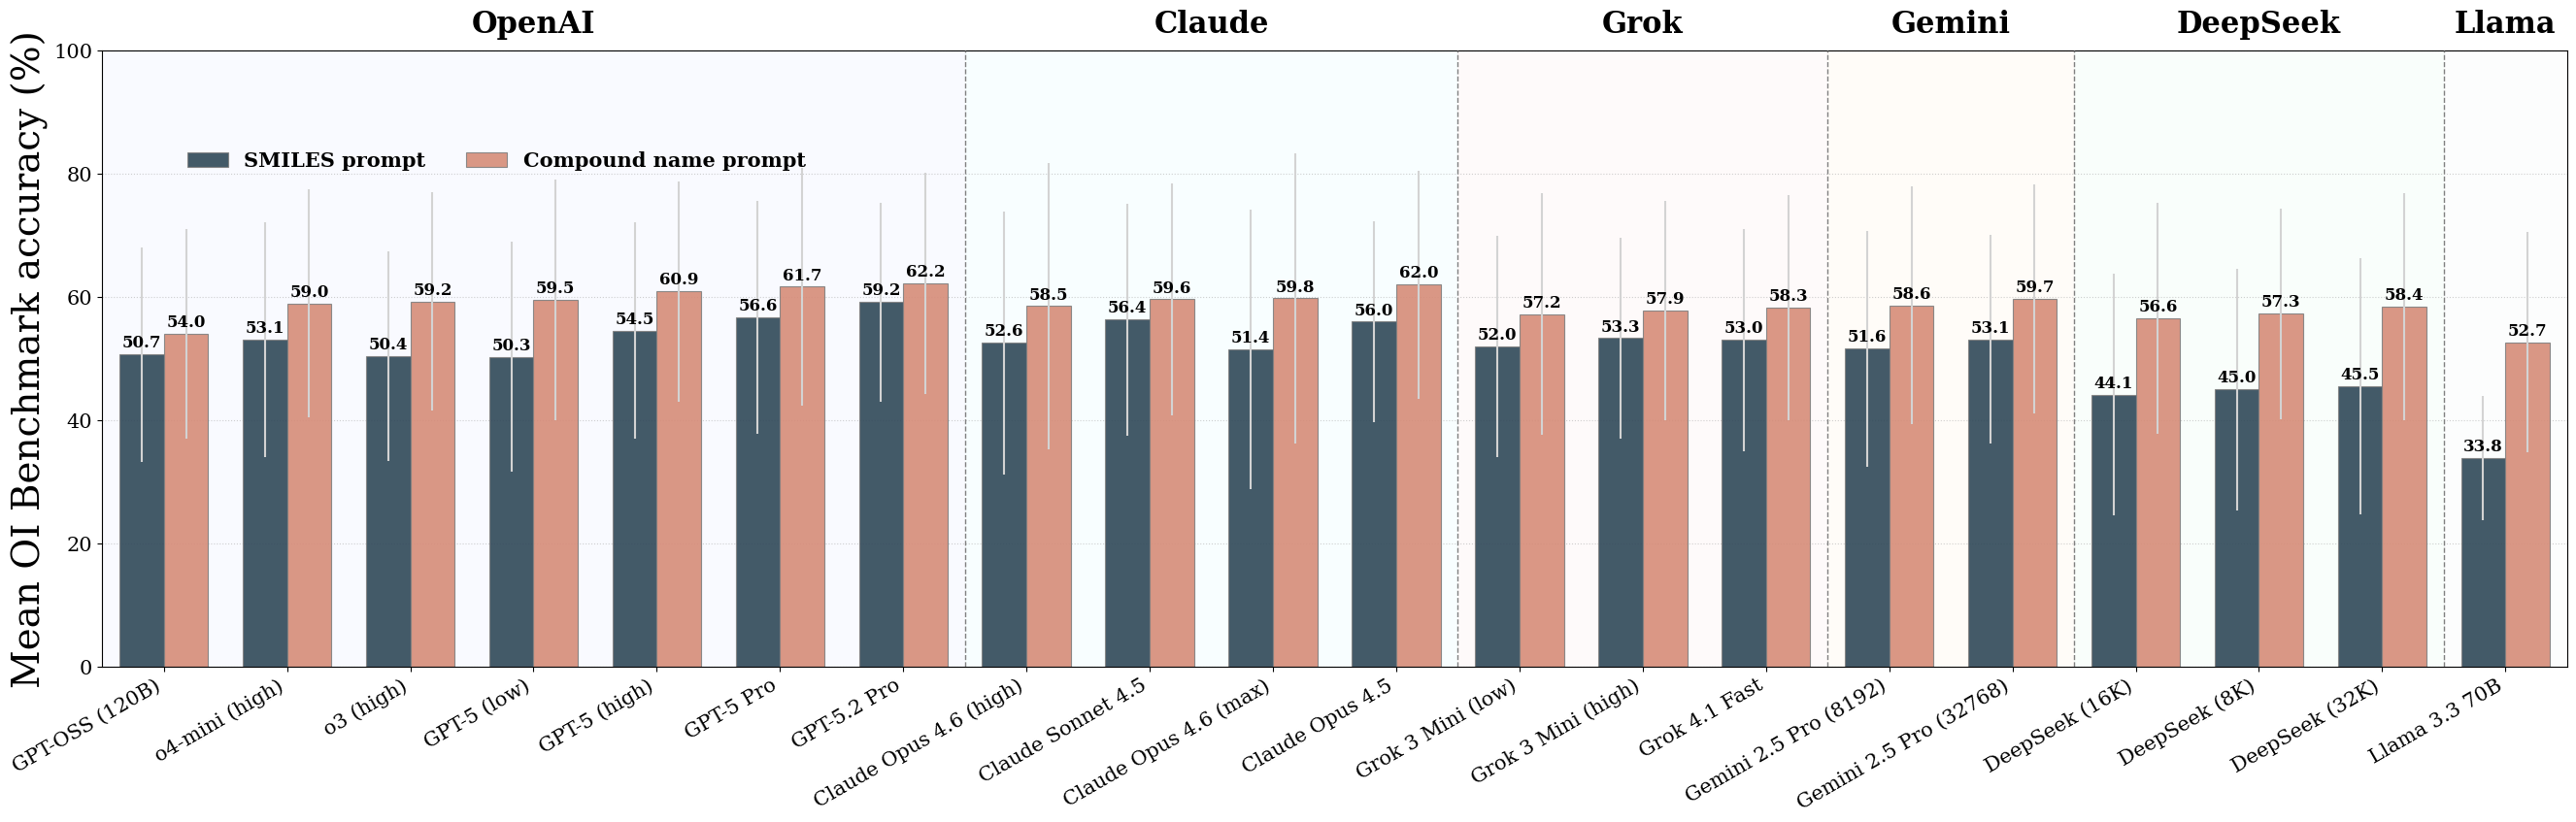

In [1]:
from pathlib import Path
import re
from typing import List, Dict, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy import stats
    _HAS_SCIPY = True
except Exception:
    stats = None
    _HAS_SCIPY = False


# Style
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 15,
    "axes.titlesize": 35,
    "axes.labelsize": 35,
})

# Config
PATTERN = "*_OI_Benchmark.csv"
DATA_DIR = Path("../Results/results_reasoning_budget")
SAVE_PATH = Path("Figure_2a.svg")
OUT_SUMMARY_CSV = Path("overall_mean_CI95_all_models.csv")

# Categories scored with multilabel F1 
MULTIANSWER_CATS = {"or_activation", "rata"}

# manual priority order within family, then alphabetical remainder.
PLOT_ORDER = [
    "gpt-4o",
    "o3",
    "gpt-5_low",
    "gpt-5_high",
    "gpt-5-pro",
    "gemini_2.5_pro_8192",
    "gemini_2.5_pro_32768",
]

# Minimal columns needed for scoring
MIN_REQUIRED_COLS = {
    "question_category",
    "answer",
    "answer_to_prompt_1",
    "answer_to_prompt_2",
}

FAMILY_ORDER = ["openai", "claude", "grok", "gemini", "deepseek", "llama", "other"]
FAMILY_SHADE = {
    "openai": "#eef2ff",
    "claude": "#ecfeff",
    "deepseek": "#f0fdf4",
    "gemini": "#fff7ed",
    "grok": "#fef2f2",
    "llama": "#f8fafc",
    "other": "#f5f5f5",
}
FAMILY_DISPLAY = {
    "openai": "OpenAI",
    "claude": "Claude",
    "deepseek": "DeepSeek",
    "gemini": "Gemini",
    "grok": "Grok",
    "llama": "Llama",
    "other": "Other",
}

# Helpers
_SPLIT_RE = re.compile(r"[;\n\r\t]+|(?<!\d),(?!\d)")
_NUMERIC_RE = re.compile(r"^[-+]?\d+(?:\.\d+)?$")

def _normalize_token(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.strip().strip("[](){}<>\"' ").lower()
    s = re.sub(r"\s+", " ", s)
    s = s.strip(".,:;!?%")
    return s

def split_items(cell: object) -> List[str]:
    """
    Convert a cell like "A; B, C" into ['a','b','c'].
    Returns [] if empty/NaN.
    """
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [_normalize_token(p) for p in parts if _normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    if not cleaned:
        single = _normalize_token(text)
        if single and not _NUMERIC_RE.fullmatch(single):
            return [single]
        return []
    return cleaned

def any_overlap(pred_items: List[str], truth_items: List[str]) -> bool:
    """Binary success: 1 if predicted set intersects truth set."""
    if not pred_items or not truth_items:
        return False
    return bool(set(pred_items) & set(truth_items))

def f1_multilabel(pred_items: List[str], truth_items: List[str]) -> float:
    """Multi-answer penalty (F1). Returns 0..1."""
    P, T = set(pred_items), set(truth_items)
    if not P and not T:
        return 1.0
    tp = len(P & T)
    fp = len(P - T)
    fn = len(T - P)
    if tp == 0:
        return 0.0
    return (2.0 * tp) / (2.0 * tp + fp + fn)

def score_by_category(df: pd.DataFrame, pred_col: str, truth_col: str = "answer") -> pd.DataFrame:
    """
    Compute per-category mean score in % for a prediction column.
    """
    preds = df[pred_col].apply(split_items)
    truths = df[truth_col].apply(split_items)
    cats = df["question_category"].astype(str).fillna("")

    scores = []
    for p, t, cat in zip(preds, truths, cats):
        cat_l = str(cat).strip().lower()
        if cat_l in MULTIANSWER_CATS:
            s = f1_multilabel(p, t)
        else:
            s = 1.0 if any_overlap(p, t) else 0.0
        scores.append(s)

    work = df.copy()
    work["_score"] = np.array(scores, dtype=float)

    agg = (
        work.groupby("question_category", dropna=False)["_score"]
        .mean()
        .mul(100.0)
        .rename("score_pct")
        .reset_index()
    )
    agg["question_category"] = agg["question_category"].astype(str)
    return agg

def mean_and_ci95(values: np.ndarray) -> Tuple[float, float, int]:
    """
    Mean and 95% CI half-width (t-based) for per-category % scores.
    Falls back to normal approximation if SciPy is unavailable.
    """
    vals = np.asarray(values, dtype=float)
    n = vals.size
    if n == 0:
        return (np.nan, np.nan, 0)
    mean_val = float(np.mean(vals))
    if n == 1:
        return (mean_val, 0.0, 1)
    sd = float(np.std(vals, ddof=1))
    sem = sd / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, df=n - 1) if _HAS_SCIPY else 1.96
    return (mean_val, sem * tcrit, n)

def model_name_from_path(p: Path) -> str:
    """ "<model>_OI_Benchmark.csv" -> "<model>" """
    name = p.name
    suf = "_OI_Benchmark.csv"
    if name.endswith(suf):
        return name[: -len(suf)]
    if name.endswith(".csv"):
        return name[:-4]
    return name

def find_csvs() -> List[Path]:
    return sorted(DATA_DIR.glob(PATTERN))

def infer_family(model_name: str) -> str:
    m = (model_name or "").strip().lower()
    if m.startswith("gpt") or re.match(r"^o\d", m):
        return "openai"
    if m.startswith("gemini"):
        return "gemini"
    if m.startswith("grok"):
        return "grok"
    if m.startswith("claude"):
        return "claude"
    if m.startswith("deepseek"):
        return "deepseek"
    if m.startswith("llama"):
        return "llama"
    return "other"

def pretty_label(model_name: str) -> str:
    """Short x-tick labels matching the current filename convention."""
    raw = (model_name or "").strip()
    m = raw.lower()

    # OpenAI o-series: o3_high -> "o3 (high)", o4_mini_high -> "o4-mini (high)"
    mo = re.match(r"^o(\d+)(?:_mini)?(?:_(.+))?$", m)
    if mo:
        base = f"o{mo.group(1)}"
        if "_mini" in m:
            base += "-mini"
        suffix = mo.group(2)
        if suffix:
            return f"{base} ({suffix})"
        return base

    # GPT models
    if m.startswith("gpt"):
        if "oss" in m:
            mm = re.search(r"(\d+b)", m, re.IGNORECASE)
            return f"GPT-OSS ({mm.group(0).upper()})" if mm else "GPT-OSS"
        if "5.2" in m:
            return "GPT-5.2 Pro"
        if re.match(r"gpt[_\-]?5", m):
            if "low" in m:
                return "GPT-5 (low)"
            if "high" in m:
                return "GPT-5 (high)"
            if "pro" in m:
                return "GPT-5 Pro"
            return "GPT-5"
        if "4o" in m:
            return "GPT-4o"
        return re.sub(r"_+", " ", raw).strip()

    # Gemini
    if m.startswith("gemini"):
        mm = re.search(r"(\d{4,6})", m)
        if mm:
            return f"Gemini 2.5 Pro ({mm.group(1)})"
        return "Gemini 2.5 Pro"

    # Claude: Claude_opus_4.6_high -> "Claude Opus 4.6 (high)"
    if m.startswith("claude"):
        parts = raw.split("_")
        if len(parts) >= 3:
            variant = parts[1].capitalize()
            version = parts[2]
            suffix = " ".join(parts[3:]) if len(parts) > 3 else ""
            base = f"Claude {variant} {version}"
            if suffix:
                return f"{base} ({suffix})"
            return base
        return re.sub(r"_+", " ", raw).strip()

    # Grok
    if m.startswith("grok"):
        if "4_1" in m or "4.1" in m:
            return "Grok 4.1 Fast"
        if "mini" in m:
            mm = re.search(r"grok[_ ](\d+)", m)
            ver = mm.group(1) if mm else ""
            if "high" in m:
                return f"Grok {ver} Mini (high)"
            if "low" in m:
                return f"Grok {ver} Mini (low)"
            return f"Grok {ver} Mini"
        return re.sub(r"_+", " ", raw).strip()

    # DeepSeek
    if m.startswith("deepseek"):
        mm = re.search(r"(\d+k)", m, re.IGNORECASE)
        if mm:
            return f"DeepSeek ({mm.group(0).upper()})"
        return "DeepSeek"

    # Llama
    if m.startswith("llama"):
        return "Llama 3.3 70B"

    # Fallback
    return re.sub(r"_+", " ", raw).strip()
files = find_csvs()

results: Dict[str, Dict[str, float]] = {}
summary_rows = []

for fp in files:
    try:
        df = pd.read_csv(fp, dtype=str, keep_default_na=True)
    except Exception as e:
        print(f"Failed to read {fp}: {e}")
        continue

    missing = MIN_REQUIRED_COLS - set(df.columns)
    if missing:
        print(f"Skipping {fp.name} (missing required columns): {sorted(missing)}")
        continue

    acc_p1 = score_by_category(df, pred_col="answer_to_prompt_1", truth_col="answer")
    acc_p2 = score_by_category(df, pred_col="answer_to_prompt_2", truth_col="answer")

    m1, ci1, n1 = mean_and_ci95(acc_p1["score_pct"].to_numpy()) if len(acc_p1) else (np.nan, np.nan, 0)
    m2, ci2, n2 = mean_and_ci95(acc_p2["score_pct"].to_numpy()) if len(acc_p2) else (np.nan, np.nan, 0)

    mname = model_name_from_path(fp)
    fam = infer_family(mname)

    results[mname] = {
        "family": fam,
        "mean_p1": float(m1) if not np.isnan(m1) else np.nan,
        "ci95_p1": 0.0 if np.isnan(ci1) else float(ci1),
        "n1": int(n1),
        "mean_p2": float(m2) if not np.isnan(m2) else np.nan,
        "ci95_p2": 0.0 if np.isnan(ci2) else float(ci2),
        "n2": int(n2),
    }

    summary_rows.append({
        "model": mname,
        "family": fam,
        "prompt": "prompt_1",
        "mean_score_pct": m1,
        "n_categories": n1,
        "ci95_halfwidth": ci1,
    })
    summary_rows.append({
        "model": mname,
        "family": fam,
        "prompt": "prompt_2",
        "mean_score_pct": m2,
        "n_categories": n2,
        "ci95_halfwidth": ci2,
    })

if not results:
    print("No matching *_OI_Benchmark.csv files found (or none matched required columns).")
else:
    # -------- Build plot order: group by family --------
    models_present = list(results.keys())
    fam_to_models: Dict[str, List[str]] = {fam: [] for fam in FAMILY_ORDER}
    for m in models_present:
        fam_to_models[results[m]["family"]].append(m)
    plot_models: List[str] = []
    for fam in FAMILY_ORDER:
        group = fam_to_models.get(fam, [])
        if not group:
            continue
        # sort within each family by compound-name prompt mean (low → high)
        group_sorted = sorted(group, key=lambda m: results[m]["mean_p2"])
        plot_models.extend(group_sorted)


    means_p1 = [results[m]["mean_p1"] for m in plot_models]
    ci95s_p1 = [results[m]["ci95_p1"] for m in plot_models]
    means_p2 = [results[m]["mean_p2"] for m in plot_models]
    ci95s_p2 = [results[m]["ci95_p2"] for m in plot_models]

    # -------- Plot --------
    x = np.arange(len(plot_models), dtype=float)
    width = 0.36
    cmap = plt.cm.cividis
    # color_p1 = cmap(0.30)
    # color_p2 = cmap(0.85)
    smiles_color = "#2F4858"  
    name_color = "#D68C78"  
    color_p1 = smiles_color
    color_p2 = name_color

    fig, ax = plt.subplots(figsize=(max(9.0, 1.4 * len(plot_models)), 9.5))

    bars1 = ax.bar(
        x - width/2,
        means_p1,
        width,
        yerr=ci95s_p1,
        capsize=0,
        label="SMILES prompt",
        color=color_p1,
        edgecolor="gray",
        ecolor="lightgray",
        linewidth=0.8,
        alpha=0.9,
        zorder=2,
    )
    bars2 = ax.bar(
        x + width/2,
        means_p2,
        width,
        yerr=ci95s_p2,
        capsize=0,
        label="Compound name prompt",
        color=color_p2,
        edgecolor="gray",
        ecolor="lightgray",
        linewidth=0.8,
        alpha=0.9,
        zorder=2,
    )

    ax.set_xticks(x)
    ax.set_xticklabels([pretty_label(m) for m in plot_models], rotation=30, ha="right")
    ax.set_ylabel("Mean OI Benchmark accuracy (%)", fontsize=28)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_xlabel("")
    ax.set_xlim(-0.5, len(plot_models) - 0.5)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(True)

    leg = ax.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.16, 0.85),
        ncol=2,
        borderaxespad=0.0,
    )
    for text in leg.get_texts():
        text.set_fontweight("semibold")

    # Annotate bars
    def _annotate_bars(bars):
        for rect in bars:
            h = rect.get_height()
            if np.isnan(h):
                label = "NA"
                ytxt = 2.0
            else:
                label = f"{h:.1f}"
                ytxt = h + 0.5
            ax.text(
                rect.get_x() + rect.get_width()/2,
                ytxt,
                label,
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="semibold",
                zorder=4,
            )

    _annotate_bars(bars1)
    _annotate_bars(bars2)

    # -------- Family shading + boundary lines + labels --------
    all_tops = []
    for m in plot_models:
        all_tops.append(results[m]["mean_p1"] + results[m]["ci95_p1"])
        all_tops.append(results[m]["mean_p2"] + results[m]["ci95_p2"])
    max_top = float(np.nanmax(all_tops)) if all_tops else 100.0
    y_top = max(100.0, max_top) + 10.0
    ax.set_ylim(0, 100)

    # contiguous segments
    segments: List[Tuple[str, int, int]] = []
    i = 0
    while i < len(plot_models):
        fam = results[plot_models[i]]["family"]
        j = i
        while j + 1 < len(plot_models) and results[plot_models[j + 1]]["family"] == fam:
            j += 1
        segments.append((fam, i, j))
        i = j + 1

    label_y = y_top - 8.2
    for idx, (fam, start, end) in enumerate(segments):
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=FAMILY_SHADE.get(fam, "#f7f7f7"),
            alpha=0.35,
            zorder=-1,
        )
        mid = (start + end) / 2.0
        ax.text(
            mid,
            label_y,
            FAMILY_DISPLAY.get(fam, fam),
            ha="center",
            va="bottom",
            fontsize=22,
            fontweight="bold",
            zorder=5,
        )

        if idx < len(segments) - 1:
            ax.axvline(
                x=end + 0.5,
                linestyle="--",
                color="gray",
                linewidth=1.0,
                zorder=3,
            )

    fig.tight_layout(rect=[0.04, 0.0, 1.0, 0.92])
    fig.savefig(SAVE_PATH, bbox_inches="tight")
    plt.show()

# Summary
if summary_rows:
    # pd.DataFrame(summary_rows).to_csv(OUT_SUMMARY_CSV, index=False)
    pass


**Accuracy by category**
Per-category accuracy for prompt 1 vs 2 (with chance/SOTA refs).


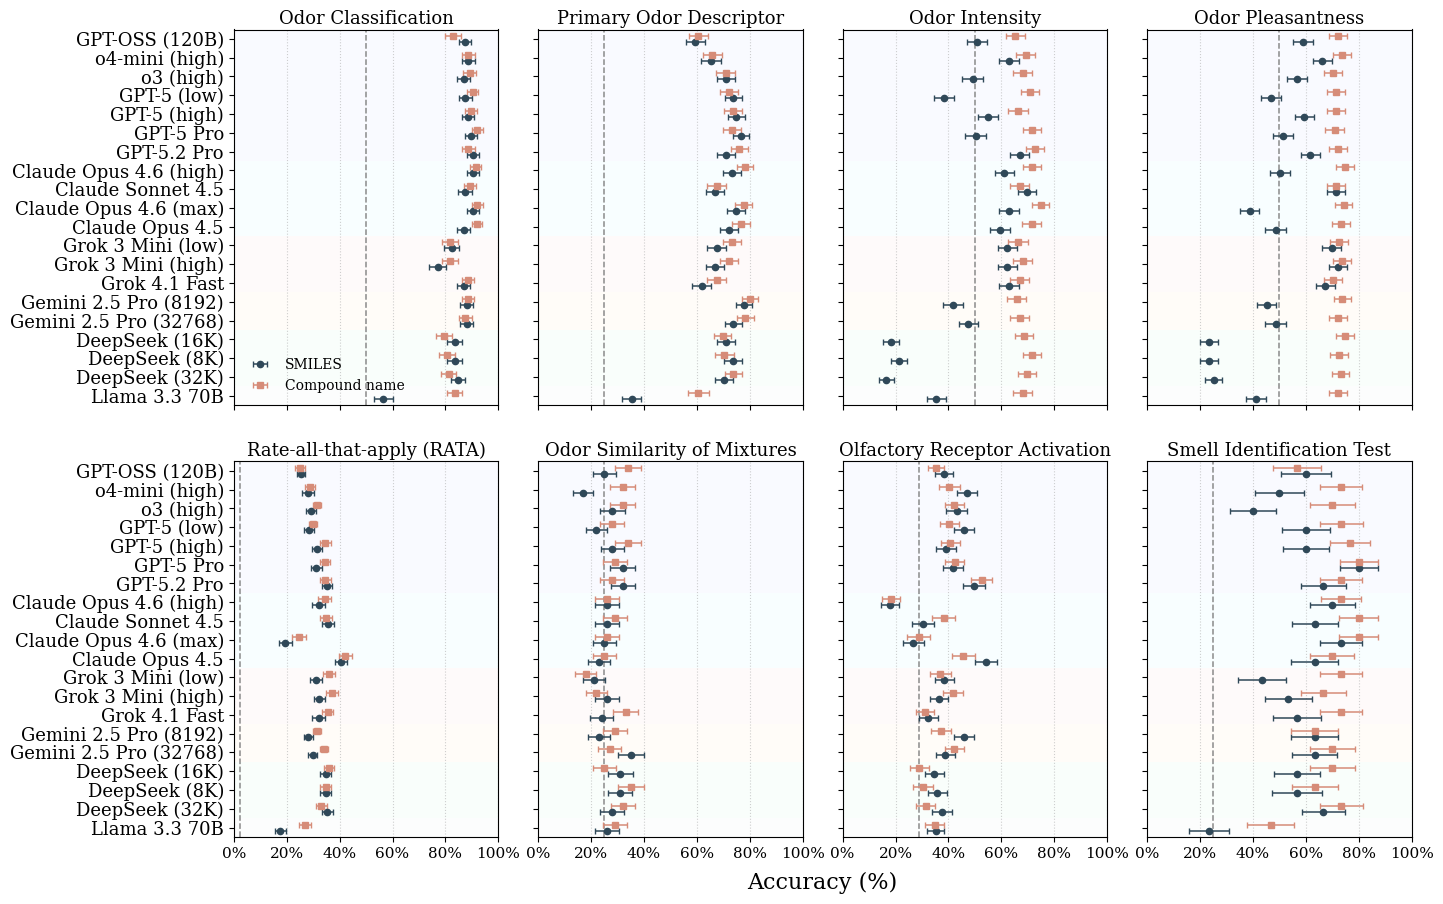

In [2]:
from pathlib import Path
import re
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Config
PATTERN = "*_OI_Benchmark.csv"
DATA_DIR = Path("../Results/results_reasoning_budget")

# Categories scored with multilabel F1 instead of simple any-overlap
MULTIANSWER_CATS = {"or_activation", "rata"}

# Reference levels
DEFAULT_CHANCE = 0.5
SOTA = 0.9

# Approximate accuracy from AUROC for balanced classes (equal-variance Gaussian assumption)
def _phi(x: float) -> float:
    import math
    return 0.5 * (1.0 + math.erf(x / (2.0 ** 0.5)))

def _phi_inv(p: float) -> float:
    import math
    # Acklam approximation for inverse normal CDF
    a = [-3.969683028665376e+01, 2.209460984245205e+02, -2.759285104469687e+02, 1.383577518672690e+02, -3.066479806614716e+01, 2.506628277459239e+00]
    b = [-5.447609879822406e+01, 1.615858368580409e+02, -1.556989798598866e+02, 6.680131188771972e+01, -1.328068155288572e+01]
    c = [-7.784894002430293e-03, -3.223964580411365e-01, -2.400758277161838e+00, -2.549732539343734e+00, 4.374664141464968e+00, 2.938163982698783e+00]
    d = [7.784695709041462e-03, 3.224671290700398e-01, 2.445134137142996e+00, 3.754408661907416e+00]
    plow = 0.02425
    phigh = 1 - plow
    if p < plow:
        q = math.sqrt(-2 * math.log(p))
        return (((((c[0]*q+c[1])*q+c[2])*q+c[3])*q+c[4])*q+c[5]) / ((((d[0]*q+d[1])*q+d[2])*q+d[3])*q+1)
    if p > phigh:
        q = math.sqrt(-2 * math.log(1-p))
        return -(((((c[0]*q+c[1])*q+c[2])*q+c[3])*q+c[4])*q+c[5]) / ((((d[0]*q+d[1])*q+d[2])*q+d[3])*q+1)
    q = p - 0.5
    r = q*q
    return (((((a[0]*r+a[1])*r+a[2])*r+a[3])*r+a[4])*r+a[5])*q / (((((b[0]*r+b[1])*r+b[2])*r+b[3])*r+b[4])*r+1)

def auc_to_acc_balanced(auc: float) -> float:
    z = _phi_inv(auc)
    return _phi(z / (2.0 ** 0.5))

# SOTA for odor classification derived from lowest reported transport-model AUROC (0.81)
ODOR_CLASS_AUC_TRANSPORT_LOW = 0.81
SOTA_BY_CAT = {
    "odor_classification": auc_to_acc_balanced(ODOR_CLASS_AUC_TRANSPORT_LOW),
}

# Smell identification clinical thresholds (convert to proportion)
THRESH_HIGH = (0.5 * (34.5 + 31.5) / 40.0)        # = 0.825
THRESH_LOW  = (0.5 * (18.5 + 16.5) / 40.0)        # = 0.4375

# Explicit category order (panel positions)
CATEGORY_ORDER = [
    "odor_classification",
    "primary_odor_descriptor",
    "odor_intensity",
    "odor_pleasantness",
    "rata",
    "mixture_similarity",
    "or_activation",
    "smell_identification",
]

CATEGORY_TITLES = {
    "odor_classification": "Odor Classification",
    "primary_odor_descriptor": "Primary Odor Descriptor",
    "odor_intensity": "Odor Intensity",
    "odor_pleasantness": "Odor Pleasantness",
    "rata": "Rate-all-that-apply (RATA)",
    "mixture_similarity": "Odor Similarity of Mixtures",
    "or_activation": "Olfactory Receptor Activation",
    "smell_identification": "Smell Identification Test",
}

# Base chance lines (category-specific)
CHANCE_BY_CAT = {
    "mixture_similarity": 0.25,
    "primary_odor_descriptor": 0.25,
    "smell_identification": 0.25,
}

# Chance aggregation for RATA / OR activation computed from OPTIONS + answer
CHANCE_AGG = "mean"  # or "median"

# Bootstrap
BOOTSTRAP_N = 1000
BOOTSTRAP_SEED = 42

# Preferred ordering if present
PLOT_ORDER = [
    "gpt-4o",
    "o3",
    "gpt-5_low",
    "gpt-5_high",
    "gpt-5-pro",
    "gemini_2.5_pro_8192",
    "gemini_2.5_pro_32768",
]

FAMILY_ORDER = ["openai", "claude", "grok", "gemini", "deepseek", "llama", "other"]
FAMILY_SHADE = {
    "openai": "#eef2ff",
    "claude": "#ecfeff",
    "deepseek": "#f0fdf4",
    "gemini": "#fff7ed",
    "grok": "#fef2f2",
    "llama": "#f8fafc",
    "other": "#f5f5f5",
}

def infer_family(model_name: str) -> str:
    m = (model_name or "").strip().lower()
    if m.startswith("gpt") or re.match(r"^o\d", m):
        return "openai"
    if m.startswith("gemini"):
        return "gemini"
    if m.startswith("grok"):
        return "grok"
    if m.startswith("claude"):
        return "claude"
    if m.startswith("deepseek"):
        return "deepseek"
    if m.startswith("llama"):
        return "llama"
    return "other"
_SPLIT_RE = re.compile(r"[;\n\r\t]+|(?<!\d),(?!\d)")
_NUMERIC_RE = re.compile(r"^[-+]?\d+(?:\.\d+)?$")

def _normalize_token(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.strip().strip("[](){}<>\"' ").lower()
    s = re.sub(r"\s+", " ", s)
    s = s.strip(".,:;!?%")
    return s

def split_items(cell: object) -> List[str]:
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [_normalize_token(p) for p in parts if _normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    if not cleaned:
        single = _normalize_token(text)
        if single and not _NUMERIC_RE.fullmatch(single):
            return [single]
        return []
    return cleaned

def split_options(cell: object) -> List[str]:
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [p.strip() for p in parts if p and p.strip()]
    return cleaned

def any_overlap(pred_items: List[str], truth_items: List[str]) -> bool:
    if not pred_items or not truth_items:
        return False
    return bool(set(pred_items) & set(truth_items))

def f1_multilabel(pred_items: List[str], truth_items: List[str]) -> float:
    P, T = set(pred_items), set(truth_items)
    if not P and not T:
        return 1.0
    tp = len(P & T)
    fp = len(P - T)
    fn = len(T - P)
    if tp == 0:
        return 0.0
    return (2.0 * tp) / (2.0 * tp + fp + fn)

def model_name_from_path(p: Path) -> str:
    name = p.name
    suf = "_OI_Benchmark.csv"
    if name.endswith(suf):
        return name[: -len(suf)]
    return name.removesuffix(".csv")

def pretty_label(model_name: str) -> str:
    """Short x-tick labels matching the current filename convention."""
    raw = (model_name or "").strip()
    m = raw.lower()

    # OpenAI o-series: o3_high -> "o3 (high)", o4_mini_high -> "o4-mini (high)"
    mo = re.match(r"^o(\d+)(?:_mini)?(?:_(.+))?$", m)
    if mo:
        base = f"o{mo.group(1)}"
        if "_mini" in m:
            base += "-mini"
        suffix = mo.group(2)
        if suffix:
            return f"{base} ({suffix})"
        return base

    # GPT models
    if m.startswith("gpt"):
        if "oss" in m:
            mm = re.search(r"(\d+b)", m, re.IGNORECASE)
            return f"GPT-OSS ({mm.group(0).upper()})" if mm else "GPT-OSS"
        if "5.2" in m:
            return "GPT-5.2 Pro"
        if re.match(r"gpt[_\-]?5", m):
            if "low" in m:
                return "GPT-5 (low)"
            if "high" in m:
                return "GPT-5 (high)"
            if "pro" in m:
                return "GPT-5 Pro"
            return "GPT-5"
        if "4o" in m:
            return "GPT-4o"
        return re.sub(r"_+", " ", raw).strip()

    # Gemini
    if m.startswith("gemini"):
        mm = re.search(r"(\d{4,6})", m)
        if mm:
            return f"Gemini 2.5 Pro ({mm.group(1)})"
        return "Gemini 2.5 Pro"

    # Claude: Claude_opus_4.6_high -> "Claude Opus 4.6 (high)"
    if m.startswith("claude"):
        parts = raw.split("_")
        if len(parts) >= 3:
            variant = parts[1].capitalize()
            version = parts[2]
            suffix = " ".join(parts[3:]) if len(parts) > 3 else ""
            base = f"Claude {variant} {version}"
            if suffix:
                return f"{base} ({suffix})"
            return base
        return re.sub(r"_+", " ", raw).strip()

    # Grok
    if m.startswith("grok"):
        if "4_1" in m or "4.1" in m:
            return "Grok 4.1 Fast"
        if "mini" in m:
            mm = re.search(r"grok[_ ](\d+)", m)
            ver = mm.group(1) if mm else ""
            if "high" in m:
                return f"Grok {ver} Mini (high)"
            if "low" in m:
                return f"Grok {ver} Mini (low)"
            return f"Grok {ver} Mini"
        return re.sub(r"_+", " ", raw).strip()

    # DeepSeek
    if m.startswith("deepseek"):
        mm = re.search(r"(\d+k)", m, re.IGNORECASE)
        if mm:
            return f"DeepSeek ({mm.group(0).upper()})"
        return "DeepSeek"

    # Llama
    if m.startswith("llama"):
        return "Llama 3.3 70B"

    # Fallback
    return re.sub(r"_+", " ", raw).strip()

def row_scores_by_category(df: pd.DataFrame, pred_col: str, truth_col: str = "answer") -> Dict[str, List[float]]:
    preds = df[pred_col].apply(split_items)
    truths = df[truth_col].apply(split_items)
    cats = df["question_category"].fillna("").astype(str).tolist()

    by_cat: Dict[str, List[float]] = {}
    for p, t, cat in zip(preds, truths, cats):
        cat_key = str(cat)
        if str(cat).strip().lower() in MULTIANSWER_CATS:
            s = f1_multilabel(p, t)
        else:
            s = 1.0 if any_overlap(p, t) else 0.0
        by_cat.setdefault(cat_key, []).append(float(s))
    return by_cat

def bootstrap_mean_sd(values: List[float], n_boot: int, rng: np.random.Generator) -> Tuple[float, float]:
    arr = np.asarray(values, dtype=float)
    if arr.size == 0:
        return (np.nan, np.nan)
    if arr.size == 1 or n_boot <= 1:
        return (float(arr.mean()), 0.0)
    idx = rng.integers(0, arr.size, size=(n_boot, arr.size))
    samples = arr[idx].mean(axis=1)
    return (float(arr.mean()), float(samples.std(ddof=1)))

def chance_from_options(df: pd.DataFrame, cat: str, agg: str = "mean") -> float:
    sub = df[df["question_category"].fillna("").astype(str).str.strip().str.lower() == cat]
    vals = []
    for _, row in sub.iterrows():
        opts = split_options(row.get("OPTIONS", ""))
        ans = split_items(row.get("answer", ""))
        if not opts or not ans:
            continue
        U = len(set(opts))
        k = len(set(ans))
        if U > 0 and k > 0:
            vals.append(k / U)
    if not vals:
        return float("nan")
    if agg == "median":
        return float(np.median(vals))
    return float(np.mean(vals))

# Load
files = sorted(DATA_DIR.glob(PATTERN))
if not files:
    print(f"No files matched pattern: {PATTERN}")
    raise SystemExit(0)

# Read all model files once
model_dfs: Dict[str, pd.DataFrame] = {}
for fp in files:
    df = pd.read_csv(fp, dtype=str, keep_default_na=True)
    model_dfs[model_name_from_path(fp)] = df

# Build category list in fixed order (filter to those present)
all_cats = set()
for df_tmp in model_dfs.values():
    all_cats.update(df_tmp["question_category"].fillna("").astype(str).tolist())
categories = [c for c in CATEGORY_ORDER if c in all_cats]

# Estimate chance for RATA + OR activation from OPTIONS + answer (first model is enough)
base_df = next(iter(model_dfs.values()))
chance_rata = chance_from_options(base_df, "rata", CHANCE_AGG)
chance_or = chance_from_options(base_df, "or_activation", CHANCE_AGG)
if not np.isnan(chance_rata):
    CHANCE_BY_CAT["rata"] = chance_rata
if not np.isnan(chance_or):
    CHANCE_BY_CAT["or_activation"] = chance_or

# Build per-model category means + bootstrap SD for prompt.1 and prompt.2
per_model: Dict[str, Dict[str, Dict[str, Tuple[float, float]]]] = {}

rng = np.random.default_rng(BOOTSTRAP_SEED)

for mname, df in model_dfs.items():
    per_model[mname] = {}

    by_cat_p1 = row_scores_by_category(df, "answer_to_prompt_1", "answer")
    by_cat_p2 = row_scores_by_category(df, "answer_to_prompt_2", "answer")

    for cat in set(list(by_cat_p1.keys()) + list(by_cat_p2.keys())):
        mean1, sd1 = bootstrap_mean_sd(by_cat_p1.get(cat, []), BOOTSTRAP_N, rng)
        mean2, sd2 = bootstrap_mean_sd(by_cat_p2.get(cat, []), BOOTSTRAP_N, rng)
        per_model[mname][cat] = {
            "p1": (mean1, sd1),
            "p2": (mean2, sd2),
        }

# Order models: family groups, sorted by prompt_2 mean (low → high)
models = list(per_model.keys())
family_map = {m: infer_family(m) for m in models}
def _overall_mean_p2(m):
    vals = [per_model[m][c]["p2"][0] for c in CATEGORY_ORDER if c in per_model[m]]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else float("nan")
ordered = []
for fam in FAMILY_ORDER:
    group = [m for m in models if family_map.get(m, "llama") == fam]
    group_sorted = sorted(group, key=_overall_mean_p2)
    ordered.extend(group_sorted)
ordered = list(reversed(ordered))
labels = [pretty_label(m) for m in ordered]
family_map = {m: infer_family(m) for m in ordered}
segments = []
i = 0
while i < len(ordered):
    fam = family_map.get(ordered[i], "llama")
    j = i
    while j + 1 < len(ordered) and family_map.get(ordered[j + 1], "llama") == fam:
        j += 1
    segments.append((i, j, fam))
    i = j + 1
# Plot
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

fig, axes = plt.subplots(2, 4, figsize=(19, 9.5), sharex=True, sharey=False)
axes = axes.ravel()

color_p1 = "#2F4858"  # SMILES color
color_p2 = "#D68C78"  # Name color
chance_color = "#8a8a8a"

for i, ax in enumerate(axes):
    if i >= len(categories):
        ax.axis("off")
        continue

    cat = categories[i]
    ax.set_title(CATEGORY_TITLES.get(cat, cat.replace("_", " ")), fontsize=13, pad=4)
    # family background bands (match bar plot colors)
    for start, end, fam in segments:
        ax.axhspan(start - 0.5, end + 0.5, facecolor=FAMILY_SHADE.get(fam, "#f8fafc"), alpha=0.35, zorder=0)
    y = np.arange(len(ordered))
    offset = 0.16

    means_p1 = [per_model[m].get(cat, {}).get("p1", (np.nan, np.nan))[0] for m in ordered]
    sds_p1   = [per_model[m].get(cat, {}).get("p1", (np.nan, np.nan))[1] for m in ordered]
    means_p2 = [per_model[m].get(cat, {}).get("p2", (np.nan, np.nan))[0] for m in ordered]
    sds_p2   = [per_model[m].get(cat, {}).get("p2", (np.nan, np.nan))[1] for m in ordered]

    ax.errorbar(
        means_p1,
        y - offset,
        xerr=sds_p1,
        fmt='o',
        markersize=4.5,
        color=color_p1,
        ecolor=color_p1,
        elinewidth=1.1,
        capsize=2.0,
        zorder=3,
        label="SMILES" if i == 0 else None,
    )
    ax.errorbar(
        means_p2,
        y + offset,
        xerr=sds_p2,
        fmt='s',
        markersize=4.2,
        color=color_p2,
        ecolor=color_p2,
        elinewidth=1.1,
        capsize=2.0,
        zorder=3,
        label="Compound name" if i == 0 else None,
    )

    # Chance + SOTA
    chance = CHANCE_BY_CAT.get(cat, DEFAULT_CHANCE)
    if chance is None or (isinstance(chance, float) and np.isnan(chance)):
        chance = DEFAULT_CHANCE
    ax.axvline(chance, color=chance_color, linestyle="--", linewidth=1.1, zorder=2)


    ax.set_xlim(0.0, 1.0)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.tick_params(axis="x", labelsize=11)
    ax.xaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=13)
    if i % 4 != 0:
        ax.tick_params(axis="y", labelleft=False)

    ax.set_ylim(len(ordered) - 0.5, -0.5)
    ax.invert_yaxis()
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(True)

# Legend (only once)
axes[0].legend(loc="lower left", frameon=False, fontsize=10)

fig.supxlabel("Accuracy (%)",x=0.67, y=0.02, fontsize=16)
fig.subplots_adjust(left=0.36, right=0.98, top=0.93, bottom=0.08, wspace=0.15, hspace=0.15)
fig.savefig("Figure_2b.svg", bbox_inches="tight")
plt.show()


**Smell identification**
Accuracy with clinical bands.


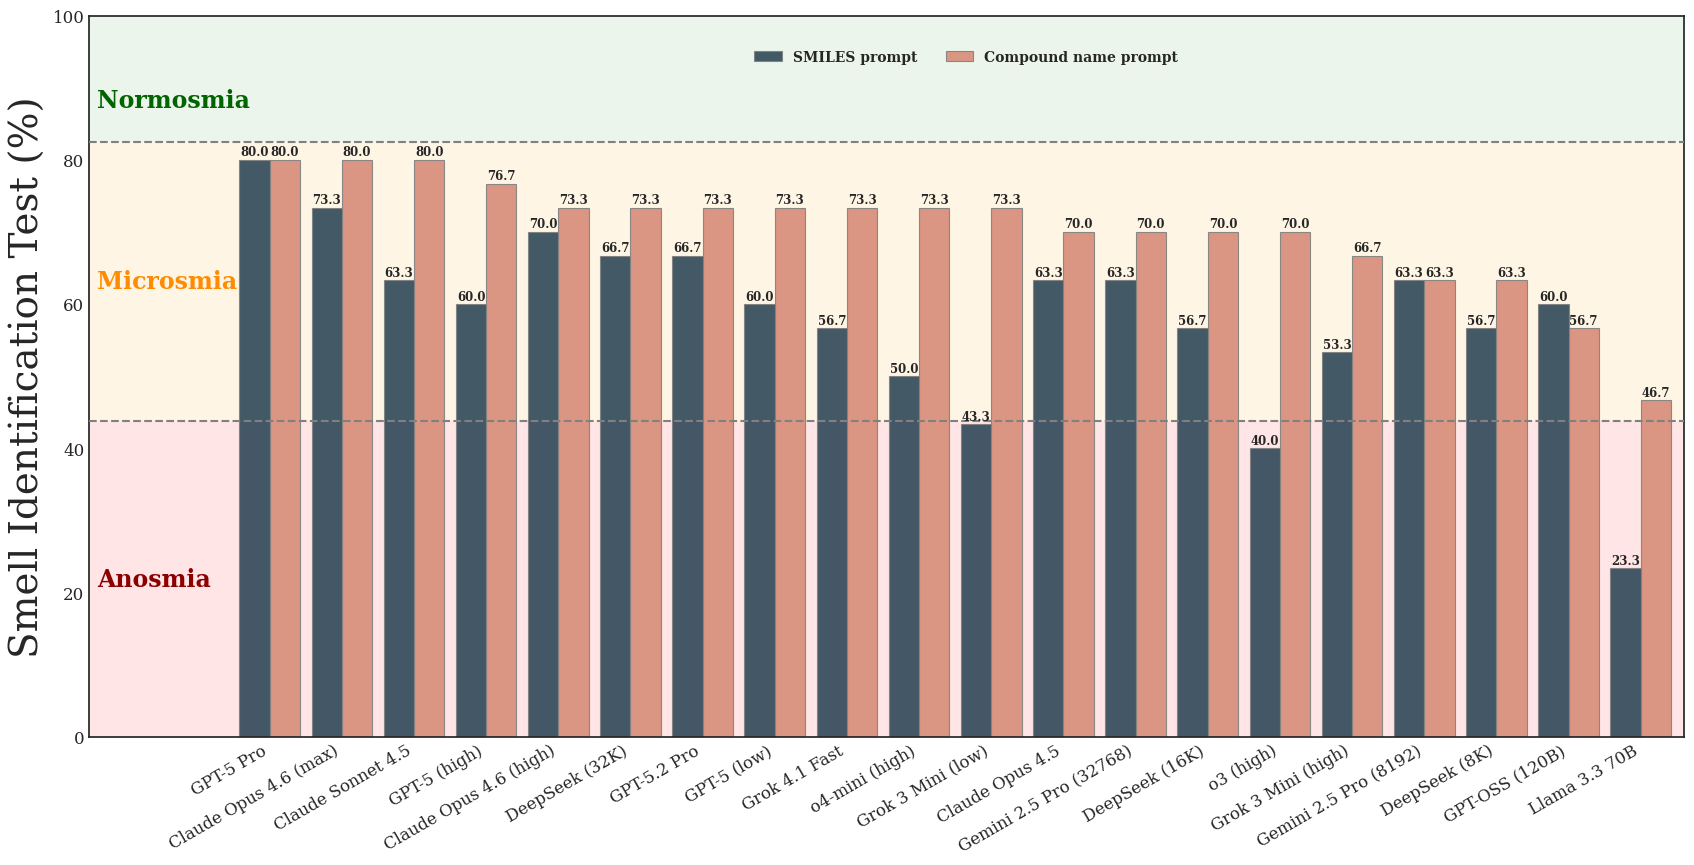

In [22]:
from pathlib import Path
import re
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Style
plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 18,
    "axes.titlesize": 35,
    "axes.labelsize": 35,
})


# Config
PATTERN = "*_OI_Benchmark.csv"
DATA_DIR = Path("../Results/results_reasoning_budget")

SAVE_PDF = Path("Figure_3.pdf")

TARGET_CATEGORY = "smell_identification"

# Thresholds (%), matching your earlier figure logic
THRESH_HIGH = (0.5 * (34.5 + 31.5) / 40.0) * 100.0  # microsmia / normosmia boundary
THRESH_LOW  = (0.5 * (18.5 + 16.5) / 40.0) * 100.0  # anosmia / microsmia boundary

REQUIRED_COLS = {
    "question_category",
    "answer",
    "answer_to_prompt_1",
    "answer_to_prompt_2",
}


# Helpers
_SPLIT_RE = re.compile(r"[;\n\r\t]+|(?<!\d),(?!\d)")
_NUMERIC_RE = re.compile(r"^[-+]?\d+(?:\.\d+)?$")

def normalize_cat(x: object) -> str:
    s = "" if x is None else str(x)
    s = s.strip().lower()
    s = re.sub(r"[\s\-]+", "_", s)   # spaces/hyphens -> underscore
    s = re.sub(r"_+", "_", s)
    return s

def _normalize_token(s: object) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.strip().strip("[](){}<>\"' ").lower()
    s = re.sub(r"\s+", " ", s)
    s = s.strip(".,:;!?%")
    return s

def split_items(cell: object) -> List[str]:
    """Convert a cell like 'A; B, C' into normalized tokens. Returns [] if empty/NaN."""
    if cell is None:
        return []
    if isinstance(cell, float) and np.isnan(cell):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [_normalize_token(p) for p in parts if _normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    if cleaned:
        return cleaned
    single = _normalize_token(text)
    if single and not _NUMERIC_RE.fullmatch(single):
        return [single]
    return []

def any_overlap(pred_items: List[str], truth_items: List[str]) -> bool:
    """Success if predicted set intersects truth set."""
    if not pred_items or not truth_items:
        return False
    return bool(set(pred_items) & set(truth_items))

def model_name_from_path(p: Path) -> str:
    """ "<model>_OI_Benchmark.csv" -> "<model>" """
    suf = "_OI_Benchmark.csv"
    name = p.name
    if name.endswith(suf):
        return name[: -len(suf)]
    return name[:-4] if name.endswith(".csv") else name

def pretty_label(model_name: str) -> str:
    """Short x-tick labels matching the current filename convention."""
    raw = (model_name or "").strip()
    m = raw.lower()

    # OpenAI o-series: o3_high -> "o3 (high)", o4_mini_high -> "o4-mini (high)"
    mo = re.match(r"^o(\d+)(?:_mini)?(?:_(.+))?$", m)
    if mo:
        base = f"o{mo.group(1)}"
        if "_mini" in m:
            base += "-mini"
        suffix = mo.group(2)
        if suffix:
            return f"{base} ({suffix})"
        return base

    # GPT models
    if m.startswith("gpt"):
        if "oss" in m:
            mm = re.search(r"(\d+b)", m, re.IGNORECASE)
            return f"GPT-OSS ({mm.group(0).upper()})" if mm else "GPT-OSS"
        if "5.2" in m:
            return "GPT-5.2 Pro"
        if re.match(r"gpt[_\-]?5", m):
            if "low" in m:
                return "GPT-5 (low)"
            if "high" in m:
                return "GPT-5 (high)"
            if "pro" in m:
                return "GPT-5 Pro"
            return "GPT-5"
        if "4o" in m:
            return "GPT-4o"
        return re.sub(r"_+", " ", raw).strip()

    # Gemini
    if m.startswith("gemini"):
        mm = re.search(r"(\d{4,6})", m)
        if mm:
            return f"Gemini 2.5 Pro ({mm.group(1)})"
        return "Gemini 2.5 Pro"

    # Claude: Claude_opus_4.6_high -> "Claude Opus 4.6 (high)"
    if m.startswith("claude"):
        parts = raw.split("_")
        if len(parts) >= 3:
            variant = parts[1].capitalize()
            version = parts[2]
            suffix = " ".join(parts[3:]) if len(parts) > 3 else ""
            base = f"Claude {variant} {version}"
            if suffix:
                return f"{base} ({suffix})"
            return base
        return re.sub(r"_+", " ", raw).strip()

    # Grok
    if m.startswith("grok"):
        if "4_1" in m or "4.1" in m:
            return "Grok 4.1 Fast"
        if "mini" in m:
            mm = re.search(r"grok[_ ](\d+)", m)
            ver = mm.group(1) if mm else ""
            if "high" in m:
                return f"Grok {ver} Mini (high)"
            if "low" in m:
                return f"Grok {ver} Mini (low)"
            return f"Grok {ver} Mini"
        return re.sub(r"_+", " ", raw).strip()

    # DeepSeek
    if m.startswith("deepseek"):
        mm = re.search(r"(\d+k)", m, re.IGNORECASE)
        if mm:
            return f"DeepSeek ({mm.group(0).upper()})"
        return "DeepSeek"

    # Llama
    if m.startswith("llama"):
        return "Llama 3.3 70B"

    # Fallback
    return re.sub(r"_+", " ", raw).strip()

def find_csvs() -> List[Path]:
    return sorted(DATA_DIR.glob(PATTERN))

def compute_accuracy_pct(df: pd.DataFrame, pred_col: str, truth_col: str = "answer") -> float:
    """
    Mean accuracy (%) across rows in df for a given prediction column.
    Row score: 100 if any_overlap(pred, truth) else 0.
    """
    preds = df[pred_col].apply(split_items)
    truths = df[truth_col].apply(split_items)
    scores = [100.0 if any_overlap(p, t) else 0.0 for p, t in zip(preds, truths)]
    return float(np.mean(scores)) if scores else float("nan")


# Main
files = find_csvs()
if not files:
    raise SystemExit(f"No files matched pattern: {PATTERN}")

records: List[Dict[str, object]] = []

for fp in files:
    try:
        df = pd.read_csv(fp, dtype=str, keep_default_na=True)
    except Exception as e:
        print(f"Failed to read {fp}: {e}")
        continue

    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        print(f"Skipping {fp.name} (missing columns): {sorted(missing)}")
        continue

    # Filter to smell_identification
    cats = df["question_category"].apply(normalize_cat)
    mask = cats.eq(TARGET_CATEGORY)
    if mask.sum() == 0:
        mask = cats.str.startswith(TARGET_CATEGORY)

    df_si = df.loc[mask].copy()
    if df_si.empty:
        print(f"Skipping {fp.name}: no rows matched question_category='{TARGET_CATEGORY}'")
        continue

    model = model_name_from_path(fp)
    acc_p1 = compute_accuracy_pct(df_si, pred_col="answer_to_prompt_1", truth_col="answer")
    acc_p2 = compute_accuracy_pct(df_si, pred_col="answer_to_prompt_2", truth_col="answer")

    records.append({
        "file": fp.name,
        "model": model,
        "n_questions_smell_identification": int(df_si.shape[0]),
        "accuracy_prompt_1_smiles_pct": acc_p1,
        "accuracy_prompt_2_name_pct": acc_p2,
    })

if not records:
    raise SystemExit("No usable files after filtering/validation.")

summary = pd.DataFrame(records)

# Ensure numeric
summary["accuracy_prompt_1_smiles_pct"] = pd.to_numeric(summary["accuracy_prompt_1_smiles_pct"], errors="coerce")
summary["accuracy_prompt_2_name_pct"] = pd.to_numeric(summary["accuracy_prompt_2_name_pct"], errors="coerce")

# One row per model (defensive: keep first if duplicates exist)
summary_first = (
    summary.sort_values(["model", "file"])
    .drop_duplicates(subset=["model"], keep="first")
    .set_index("model")
)

# Order by prompt_2 desc, then prompt_1 desc
plot_models = sorted(
    summary_first.index.tolist(),
    key=lambda m: (
        float(summary_first.loc[m, "accuracy_prompt_2_name_pct"]),
        float(summary_first.loc[m, "accuracy_prompt_1_smiles_pct"]),
    ),
    reverse=True,
)

means_p1 = [float(summary_first.loc[m, "accuracy_prompt_1_smiles_pct"]) for m in plot_models]
means_p2 = [float(summary_first.loc[m, "accuracy_prompt_2_name_pct"]) for m in plot_models]

# Plot
base_x = np.arange(len(plot_models), dtype=float)
shift = 2.3
x = base_x + shift
width = 0.42

color_p1 = "#2F4858"
color_p2 = "#D68C78"

# fig, ax = plt.subplots(figsize=(max(9.0, 1.4 * len(plot_models)), 10.5))
fig, ax = plt.subplots(figsize=(18.0, 10.0))

# Shaded clinical bands
ax.axhspan(0, THRESH_LOW, facecolor="red", alpha=0.10, zorder=0)
ax.axhspan(THRESH_LOW, THRESH_HIGH, facecolor="orange", alpha=0.10, zorder=0)
ax.axhspan(THRESH_HIGH, 100, facecolor="green", alpha=0.08, zorder=0)

# Bars (NO error bars)
bars1 = ax.bar(
    x - width/2, means_p1, width,
    label="SMILES prompt",
    color=color_p1, edgecolor="gray", linewidth=0.8, alpha=0.9, zorder=2,
)
bars2 = ax.bar(
    x + width/2, means_p2, width,
    label="Compound name prompt",
    color=color_p2, edgecolor="gray", linewidth=0.8, alpha=0.9, zorder=2,
)

# Cutoff lines
ax.axhline(THRESH_LOW,  linestyle="--", linewidth=1.5, color="gray", zorder=3)
ax.axhline(THRESH_HIGH, linestyle="--", linewidth=1.5, color="gray", zorder=3)

# Left labels
trans = ax.get_yaxis_transform()
x_label = 0.005

y_ano_center   = (0 + THRESH_LOW) / 2.0
y_micro_center = (THRESH_LOW + THRESH_HIGH) / 2.0
y_norm_center  = (THRESH_HIGH + 100.0) / 2.0 - 3.0

ax.text(x_label, y_ano_center, "Anosmia", transform=trans,
        ha="left", va="center", fontsize=17, fontweight="bold",
        color="darkred", clip_on=False, zorder=4)
ax.text(x_label, y_micro_center, "Microsmia", transform=trans,
        ha="left", va="center", fontsize=17, fontweight="bold",
        color="darkorange", clip_on=False, zorder=4)
ax.text(x_label, y_norm_center, "Normosmia", transform=trans,
        ha="left", va="center", fontsize=17, fontweight="bold",
        color="darkgreen", clip_on=False, zorder=4)

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels([pretty_label(m) for m in plot_models], rotation=30, ha="right")

ax.set_ylabel("Smell Identification Test (%)", fontsize=28)
ax.set_ylim(0, 100)
ax.set_xlim(-0.2, x[-1] + 0.6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(True)

leg = ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.55, 0.97), ncol=2)
for t in leg.get_texts():
    t.set_fontweight("semibold")

# Value labels
def annotate(bars):
    for rect in bars:
        h = rect.get_height()
        label = "NA" if np.isnan(h) else f"{h:.1f}"
        ytxt = 2.0 if np.isnan(h) else h + 0.2
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            ytxt,
            label,
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="semibold",
            zorder=4,
        )

annotate(bars1)
annotate(bars2)

fig.tight_layout(rect=[0.04, 0.0, 1.0, 0.9])
fig.savefig(SAVE_PDF, bbox_inches="tight")
plt.show()




**Correlations (SMILES vs name)**
Significant correlations only (p≤0.05).


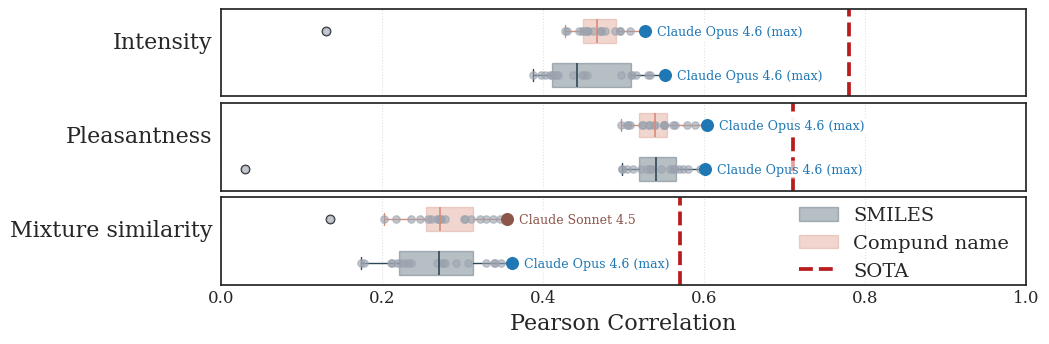

In [4]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Config
PATTERN = "*_OI_Benchmark.csv"
DATA_DIR = Path("../Results/results_reasoning_budget")
CATS = [ "odor_intensity", "odor_pleasantness","mixture_similarity"]
CAT_LABELS = {
    "odor_intensity": "Intensity",
    "odor_pleasantness": "Pleasantness",
    "mixture_similarity": "Mixture similarity",
}
SOTA = {
    "mixture_similarity": 0.57,
    "odor_intensity": 0.78,
    "odor_pleasantness": 0.71,
}
PROMPTS = [("SMILES (prompt.1)", "answer_to_prompt_1"), ("Name (prompt.2)", "answer_to_prompt_2")]
N_PERM = 5000
SEED = 42

# Parsers
NUM_ANY_RE   = re.compile(r"[-+]?\d+(?:\.\d+)?")
AFTER_EQ_RE  = re.compile(r"=\s*([-+]?\d+(?:\.\d+)?)")

def nums_after_equals(text: str, max_take: int) -> list:
    if text is None:
        return []
    return [float(m.group(1)) for m in AFTER_EQ_RE.finditer(str(text))][:max_take]

def last_two_nums_from_semicol_field(text: str) -> list:
    if text is None:
        return []
    parts = [p.strip() for p in str(text).split(";")]
    out = []
    for tok in reversed(parts):
        m = NUM_ANY_RE.search(tok)
        if m:
            try:
                out.append(float(m.group(0)))
            except ValueError:
                pass
        if len(out) == 2:
            break
    return list(reversed(out))

def last_num_from_semicol_field(text: str) -> float:
    if text is None:
        return float("nan")
    parts = [p.strip() for p in str(text).split(";")]
    for tok in reversed(parts):
        m = NUM_ANY_RE.search(tok)
        if m:
            try:
                return float(m.group(0))
            except ValueError:
                pass
    m2 = NUM_ANY_RE.search(str(text))
    return float(m2.group(0)) if m2 else float("nan")

def first_num_after_equals(text: str) -> float:
    if text is None:
        return float("nan")
    m = AFTER_EQ_RE.search(str(text))
    if m:
        try:
            return float(m.group(1))
        except ValueError:
            pass
    m2 = NUM_ANY_RE.search(str(text))
    return float(m2.group(0)) if m2 else float("nan")

# Stats
def pearson_corr(x: np.ndarray, y: np.ndarray) -> float:
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if x.size < 3:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])

def paired_pvalue(a: np.ndarray, b: np.ndarray, rng: np.random.Generator) -> float:
    m = np.isfinite(a) & np.isfinite(b)
    a = a[m]
    b = b[m]
    if a.size < 3:
        return float("nan")
    d = a - b
    obs = float(d.mean())
    if np.allclose(d, 0):
        return 1.0
    signs = rng.choice([-1, 1], size=(N_PERM, d.size))
    perm_means = (signs * d).mean(axis=1)
    p = (np.sum(np.abs(perm_means) >= abs(obs)) + 1) / (N_PERM + 1)
    return float(p)

def extract_xy(df: pd.DataFrame, prompt_col: str, category: str):
    if category in ("odor_intensity", "odor_pleasantness"):
        gt12 = df["other_info"].apply(lambda s: nums_after_equals(s, 2))
        p12  = df[prompt_col].apply(last_two_nums_from_semicol_field)
        xs, ys = [], []
        for gt, pp in zip(gt12, p12):
            if len(gt) >= 2 and len(pp) >= 2:
                xs.extend([gt[0], gt[1]])
                ys.extend([pp[0], pp[1]])
        return np.asarray(xs, float), np.asarray(ys, float)
    else:
        gt = df["other_info"].apply(first_num_after_equals).astype(float).to_numpy()
        pred = df[prompt_col].apply(last_num_from_semicol_field).astype(float).to_numpy()
        return gt, pred

def model_name_from_path(p: Path) -> str:
    name = p.name
    suf = "_OI_Benchmark.csv"
    if name.endswith(suf):
        return name[: -len(suf)]
    return name.removesuffix(".csv")

def pretty_label(model_name: str) -> str:
    """Short x-tick labels matching the current filename convention."""
    raw = (model_name or "").strip()
    m = raw.lower()

    # OpenAI o-series: o3_high -> "o3 (high)", o4_mini_high -> "o4-mini (high)"
    mo = re.match(r"^o(\d+)(?:_mini)?(?:_(.+))?$", m)
    if mo:
        base = f"o{mo.group(1)}"
        if "_mini" in m:
            base += "-mini"
        suffix = mo.group(2)
        if suffix:
            return f"{base} ({suffix})"
        return base

    # GPT models
    if m.startswith("gpt"):
        if "oss" in m:
            mm = re.search(r"(\d+b)", m, re.IGNORECASE)
            return f"GPT-OSS ({mm.group(0).upper()})" if mm else "GPT-OSS"
        if "5.2" in m:
            return "GPT-5.2 Pro"
        if re.match(r"gpt[_\-]?5", m):
            if "low" in m:
                return "GPT-5 (low)"
            if "high" in m:
                return "GPT-5 (high)"
            if "pro" in m:
                return "GPT-5 Pro"
            return "GPT-5"
        if "4o" in m:
            return "GPT-4o"
        return re.sub(r"_+", " ", raw).strip()

    # Gemini
    if m.startswith("gemini"):
        mm = re.search(r"(\d{4,6})", m)
        if mm:
            return f"Gemini 2.5 Pro ({mm.group(1)})"
        return "Gemini 2.5 Pro"

    # Claude: Claude_opus_4.6_high -> "Claude Opus 4.6 (high)"
    if m.startswith("claude"):
        parts = raw.split("_")
        if len(parts) >= 3:
            variant = parts[1].capitalize()
            version = parts[2]
            suffix = " ".join(parts[3:]) if len(parts) > 3 else ""
            base = f"Claude {variant} {version}"
            if suffix:
                return f"{base} ({suffix})"
            return base
        return re.sub(r"_+", " ", raw).strip()

    # Grok
    if m.startswith("grok"):
        if "4_1" in m or "4.1" in m:
            return "Grok 4.1 Fast"
        if "mini" in m:
            mm = re.search(r"grok[_ ](\d+)", m)
            ver = mm.group(1) if mm else ""
            if "high" in m:
                return f"Grok {ver} Mini (high)"
            if "low" in m:
                return f"Grok {ver} Mini (low)"
            return f"Grok {ver} Mini"
        return re.sub(r"_+", " ", raw).strip()

    # DeepSeek
    if m.startswith("deepseek"):
        mm = re.search(r"(\d+k)", m, re.IGNORECASE)
        if mm:
            return f"DeepSeek ({mm.group(0).upper()})"
        return "DeepSeek"

    # Llama
    if m.startswith("llama"):
        return "Llama 3.3 70B"

    # Fallback
    return re.sub(r"_+", " ", raw).strip()
files = sorted(DATA_DIR.glob(PATTERN))
required = {"question_category", "other_info", "answer_to_prompt_1", "answer_to_prompt_2"}
if not files:
    print("No *_OI_Benchmark.csv files found.")
    raise SystemExit(0)

corr = {pname: {cat: [] for cat in CATS} for pname, _ in PROMPTS}

for fp in files:
    try:
        df = pd.read_csv(fp, dtype=str, keep_default_na=True)
    except Exception:
        continue
    if not required.issubset(df.columns):
        continue
    df["__cat"] = df["question_category"].astype(str).str.strip().str.lower()

    for pname, pcol in PROMPTS:
        for cat in CATS:
            sub = df[df["__cat"] == cat].copy()
            if sub.empty:
                continue
            x, y = extract_xy(sub, pcol, cat)
            if x.size < 3 or y.size < 3:
                continue
            r = pearson_corr(x, y)
            if np.isfinite(r):
                corr[pname][cat].append((model_name_from_path(fp), r))

# identify best model per category+prompt
best_models = {}
for pname, _ in PROMPTS:
    for cat in CATS:
        if corr[pname][cat]:
            best_models[(pname, cat)] = max(corr[pname][cat], key=lambda t: t[1])

unique_best_models = sorted({m for (m, _r) in best_models.values()})
best_colors = dict(zip(unique_best_models, plt.cm.tab10(np.linspace(0, 1, max(3, len(unique_best_models))))))

# p-values comparing SMILES vs Name within each category
rng = np.random.default_rng(SEED)
pvals = {}
for cat in CATS:
    sm_map = {m: r for m, r in corr[PROMPTS[0][0]][cat]}
    nm_map = {m: r for m, r in corr[PROMPTS[1][0]][cat]}
    shared = sorted(set(sm_map) & set(nm_map))
    if len(shared) < 3:
        pvals[cat] = float("nan")
        continue
    a = np.asarray([sm_map[m] for m in shared], float)
    b = np.asarray([nm_map[m] for m in shared], float)
    pvals[cat] = paired_pvalue(a, b, rng)

# Plot
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
})

fig, axes = plt.subplots(3, 1, figsize=(10.2, 3.2), sharex=True)
plt.subplots_adjust(hspace=0.08, left=0.18, right=0.97, top=0.96, bottom=0.10)

smiles_color = "#2F4858"
name_color = "#D68C78"
gray = "#9ca3af"
sota_color = "#b91c1c"



for ax, cat in zip(axes, CATS):
    vals_sm = [r for _, r in corr[PROMPTS[0][0]][cat]]
    vals_nm = [r for _, r in corr[PROMPTS[1][0]][cat]]

    # boxplots
    ax.boxplot([vals_sm], positions=[0], vert=False, widths=0.55, patch_artist=True,
               boxprops=dict(facecolor=smiles_color, edgecolor=smiles_color, alpha=0.35),
               medianprops=dict(color=smiles_color, linewidth=1.2),
               whiskerprops=dict(color=smiles_color),
               capprops=dict(color=smiles_color))
    ax.boxplot([vals_nm], positions=[1], vert=False, widths=0.55, patch_artist=True,
               boxprops=dict(facecolor=name_color, edgecolor=name_color, alpha=0.35),
               medianprops=dict(color=name_color, linewidth=1.2),
               whiskerprops=dict(color=name_color),
               capprops=dict(color=name_color))

    # model points
    ax.scatter(vals_sm, [0]*len(vals_sm), color=gray, s=28, alpha=0.6, zorder=2)
    ax.scatter(vals_nm, [1]*len(vals_nm), color=gray, s=28, alpha=0.6, zorder=2)

    # best model per prompt/category
    bm_sm = best_models.get((PROMPTS[0][0], cat))
    if bm_sm:
        ax.scatter(bm_sm[1], 0, color=best_colors[bm_sm[0]], s=70, zorder=4)
        ax.text(bm_sm[1] + 0.015, -0.10, pretty_label(bm_sm[0]), fontsize=9, color=best_colors[bm_sm[0]],
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"))
    bm_nm = best_models.get((PROMPTS[1][0], cat))
    if bm_nm:
        ax.scatter(bm_nm[1], 1, color=best_colors[bm_nm[0]], s=70, zorder=4)
        ax.text(bm_nm[1] + 0.015, 0.90, pretty_label(bm_nm[0]), fontsize=9, color=best_colors[bm_nm[0]],
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.95, edgecolor="none"))

    # SOTA diamond
    if cat in SOTA:
        ax.axvline(SOTA[cat], color=sota_color, linestyle="--", linewidth=2.7, zorder=2)


    ax.set_yticks([])
    ax.set_ylabel(CAT_LABELS.get(cat, cat.replace("_", " ")), rotation=0)
    ax.yaxis.set_label_coords(-0.01, 0.5)  # move left (more negative = farther left)
    ax.yaxis.label.set_horizontalalignment('right')

    ax.set_xlim(0.0, 1.0)
    ax.xaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Pearson Correlation")

from matplotlib.lines import Line2D
legend_handles = [
    Patch(facecolor=smiles_color, edgecolor=smiles_color, alpha=0.35, label="SMILES"),
    Patch(facecolor=name_color, edgecolor=name_color, alpha=0.35, label="Compund name"),
    Line2D([0], [0], color=sota_color, linestyle="--",linewidth=2.7, label="SOTA"),
]
axes[-1].legend(handles=legend_handles, frameon=False, loc="lower right",bbox_to_anchor=(1.0, -0.15))

fig.savefig("Figure_4a.svg", bbox_inches="tight")
plt.show()


**Label difficulty (RATA / ORA)**
Mean per-label F1 across models.


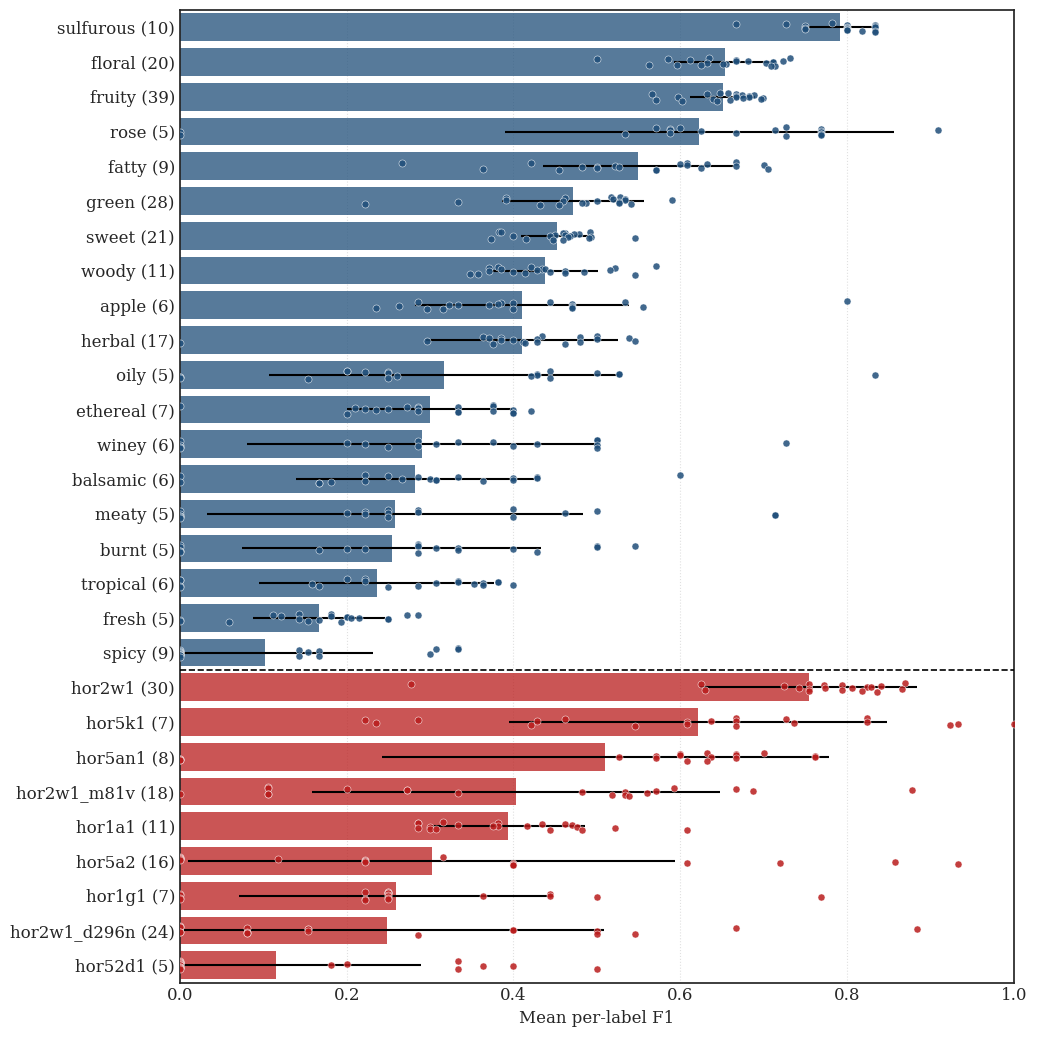

In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config
DATA_DIR = Path("../Results/results_reasoning_budget")
PATTERN = "*_OI_Benchmark.csv"
CATEGORIES = ["rata", "or_activation"]
PRED_COL = "answer_to_prompt_2"  # set to answer_to_prompt_1 if needed
N_SPAN = 20    # number of labels to show spanning worst->best per category
MIN_POS = 5    # minimum average positive count to include label

# Colors
COLOR_RATA = "#1f4e79"  # deep blue
COLOR_OR   = "#b91c1c"  # deep red

# Helpers
_SPLIT_RE = re.compile(r"[;\n\r\t]+|(?<!\d),(?!\d)")
_NUMERIC_RE = re.compile(r"^[-+]?\d+(?:\.\d+)?$")

def normalize_token(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[\"'\[\]{}()<>.,:;!?%]+", "", s)
    s = re.sub(r"\s+", " ", s)
    return s

def split_items(cell: object):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [normalize_token(p) for p in parts if normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    return cleaned

def split_options(cell: object):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [normalize_token(p) for p in parts if normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    return cleaned

def model_name_from_path(p: Path) -> str:
    name = p.name
    suf = "_OI_Benchmark.csv"
    if name.endswith(suf):
        return name[: -len(suf)]
    return name.removesuffix(".csv")

def pretty_label(model_name: str) -> str:
    """Short x-tick labels matching the current filename convention."""
    raw = (model_name or "").strip()
    m = raw.lower()

    # OpenAI o-series: o3_high -> "o3 (high)", o4_mini_high -> "o4-mini (high)"
    mo = re.match(r"^o(\d+)(?:_mini)?(?:_(.+))?$", m)
    if mo:
        base = f"o{mo.group(1)}"
        if "_mini" in m:
            base += "-mini"
        suffix = mo.group(2)
        if suffix:
            return f"{base} ({suffix})"
        return base

    # GPT models
    if m.startswith("gpt"):
        if "oss" in m:
            mm = re.search(r"(\d+b)", m, re.IGNORECASE)
            return f"GPT-OSS ({mm.group(0).upper()})" if mm else "GPT-OSS"
        if "5.2" in m:
            return "GPT-5.2 Pro"
        if re.match(r"gpt[_\-]?5", m):
            if "low" in m:
                return "GPT-5 (low)"
            if "high" in m:
                return "GPT-5 (high)"
            if "pro" in m:
                return "GPT-5 Pro"
            return "GPT-5"
        if "4o" in m:
            return "GPT-4o"
        return re.sub(r"_+", " ", raw).strip()

    # Gemini
    if m.startswith("gemini"):
        mm = re.search(r"(\d{4,6})", m)
        if mm:
            return f"Gemini 2.5 Pro ({mm.group(1)})"
        return "Gemini 2.5 Pro"

    # Claude: Claude_opus_4.6_high -> "Claude Opus 4.6 (high)"
    if m.startswith("claude"):
        parts = raw.split("_")
        if len(parts) >= 3:
            variant = parts[1].capitalize()
            version = parts[2]
            suffix = " ".join(parts[3:]) if len(parts) > 3 else ""
            base = f"Claude {variant} {version}"
            if suffix:
                return f"{base} ({suffix})"
            return base
        return re.sub(r"_+", " ", raw).strip()

    # Grok
    if m.startswith("grok"):
        if "4_1" in m or "4.1" in m:
            return "Grok 4.1 Fast"
        if "mini" in m:
            mm = re.search(r"grok[_ ](\d+)", m)
            ver = mm.group(1) if mm else ""
            if "high" in m:
                return f"Grok {ver} Mini (high)"
            if "low" in m:
                return f"Grok {ver} Mini (low)"
            return f"Grok {ver} Mini"
        return re.sub(r"_+", " ", raw).strip()

    # DeepSeek
    if m.startswith("deepseek"):
        mm = re.search(r"(\d+k)", m, re.IGNORECASE)
        if mm:
            return f"DeepSeek ({mm.group(0).upper()})"
        return "DeepSeek"

    # Llama
    if m.startswith("llama"):
        return "Llama 3.3 70B"

    # Fallback
    return re.sub(r"_+", " ", raw).strip()
files = sorted(DATA_DIR.glob(PATTERN))
required = {"question_category", "OPTIONS", "answer", PRED_COL}

model_dfs = []
for fp in files:
    try:
        df = pd.read_csv(fp, dtype=str, keep_default_na=True)
    except Exception:
        continue
    if not required.issubset(df.columns):
        continue
    model_dfs.append((model_name_from_path(fp), df))

if not model_dfs:
    print("No RATA/OR results found.")
    raise SystemExit(0)

# Per-category label difficulty
category_results = {}
model_f1_by_cat = {}
model_names_by_cat = {}
for CATEGORY in CATEGORIES:
    # filter per category
    dfs = []
    for mname, df in model_dfs:
        sub = df[df["question_category"].astype(str).str.strip().str.lower() == CATEGORY].copy()
        if sub.empty:
            continue
        dfs.append((mname, sub))

    if not dfs:
        continue

    model_names = [m for m, _ in dfs]

    # Build label set
    label_set = set()
    for _, df in dfs:
        for _, row in df.iterrows():
            label_set.update(split_options(row.get("OPTIONS", "")))
    labels = sorted(label_set)

    # Per-label stats by model
    label_stats = {lab: [] for lab in labels}  # list of (f1, support) per model
    model_f1 = {m: {} for m in model_names}

    for model, df in dfs:
        TP = {lab: 0 for lab in labels}
        FP = {lab: 0 for lab in labels}
        FN = {lab: 0 for lab in labels}
        SUP = {lab: 0 for lab in labels}

        for _, row in df.iterrows():
            opts = split_options(row.get("OPTIONS", ""))
            if not opts:
                continue
            truth = set(split_items(row.get("answer", "")))
            pred = set(split_items(row.get(PRED_COL, "")))
            for lab in opts:
                t = lab in truth
                p = lab in pred
                if t and p:
                    TP[lab] += 1
                elif t and not p:
                    FN[lab] += 1
                elif (not t) and p:
                    FP[lab] += 1
                if t:
                    SUP[lab] += 1

        for lab in labels:
            tp, fp, fn = TP[lab], FP[lab], FN[lab]
            if tp == 0:
                f1 = 0.0
            else:
                f1 = (2.0 * tp) / (2.0 * tp + fp + fn)
            label_stats[lab].append((f1, SUP[lab]))
            model_f1[model][lab] = f1

    # Aggregate mean+std
    rows = []
    for lab, entries in label_stats.items():
        vals = [f1 for f1, _sup in entries]
        sups = [sup for _f1, sup in entries]
        if np.mean(sups) < MIN_POS:
            continue
        rows.append({
            "label": lab,
            "mean": float(np.mean(vals)) if vals else np.nan,
            "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
            "n": int(np.mean(sups))
        })

    df_stats = pd.DataFrame(rows).dropna(subset=["mean"])
    if df_stats.empty:
        continue

    df_stats = df_stats.sort_values("mean", ascending=False)
    # take evenly spaced labels from worst to best
    if len(df_stats) > N_SPAN:
        idxs = np.linspace(0, len(df_stats) - 1, N_SPAN).round().astype(int)
        df_stats = df_stats.iloc[idxs]
    category_results[CATEGORY] = df_stats.reset_index(drop=True)
    model_f1_by_cat[CATEGORY] = model_f1
    model_names_by_cat[CATEGORY] = model_names

# Plot
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

# Build combined plot
fig, ax = plt.subplots(figsize=(10.5, 10.5))

y_labels = []
raw_labels = []
cat_labels = []
means = []
errs = []
colors = []

# RATA first
rata = category_results.get("rata")
if rata is not None:
    for _, row in rata.iterrows():
        raw_labels.append(row["label"])
        cat_labels.append("rata")
        y_labels.append(f"{row['label']} ({int(row['n'])})")
        means.append(row['mean'])
        errs.append(row['std'])
        colors.append(COLOR_RATA)

# separator line
sep_index = len(y_labels)

# OR activation
or_df = category_results.get("or_activation")
if or_df is not None:
    for _, row in or_df.iterrows():
        raw_labels.append(row["label"])
        cat_labels.append("or_activation")
        y_labels.append(f"{row['label']} ({int(row['n'])})")
        means.append(row['mean'])
        errs.append(row['std'])
        colors.append(COLOR_OR)

# positions
y = np.arange(len(y_labels))

# bars with error
ax.barh(y, means, xerr=errs, color=colors, alpha=0.75, edgecolor="none", zorder=2)
# overlay per-model F1 circles
offset = 0.12
for i_lab, raw in enumerate(raw_labels):
    cat = cat_labels[i_lab]
    if cat in model_f1_by_cat:
        vals = [model_f1_by_cat[cat].get(m, {}).get(raw, np.nan) for m in model_names_by_cat[cat]]
        vals = [v for v in vals if np.isfinite(v)]
        if vals:
            y0 = i_lab
            jit = np.linspace(-offset, offset, len(vals)) if len(vals) > 1 else [0.0]
            ax.scatter(
                vals,
                [y0 + j for j in jit],
                s=26,
                facecolor=colors[i_lab],
                edgecolor="white",
                linewidth=0.4,
                alpha=0.85,
                zorder=3,
            )
# separator line between sections
ax.axhline(sep_index - 0.5, color="black", linestyle="--", linewidth=1.2, zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(y_labels)
ax.invert_yaxis()
ax.set_ylim(len(y_labels) - 0.5, -0.5)
ax.set_xlabel("Mean per-label F1")
ax.set_xlim(0, 1)
ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.6)

# legend
# ax.text(0.02, 0.98, "RATA", transform=ax.transAxes, color=COLOR_RATA, va="top", fontsize=11, fontweight="bold")
# ax.text(0.02, 0.94, "OR activation", transform=ax.transAxes, color=COLOR_OR, va="top", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("Figure_4b.svg", bbox_inches="tight")
plt.show()


**RATA ROC**
vote-fraction across translations.

  Grok 4.1 Fast: 21 languages loaded
  GPT-5 (high): 21 languages loaded
  GPT-5.2 Pro: 21 languages loaded
  Claude Opus 4.6 (high): 21 languages loaded
  DeepSeek Reasoner (32K): 21 languages loaded


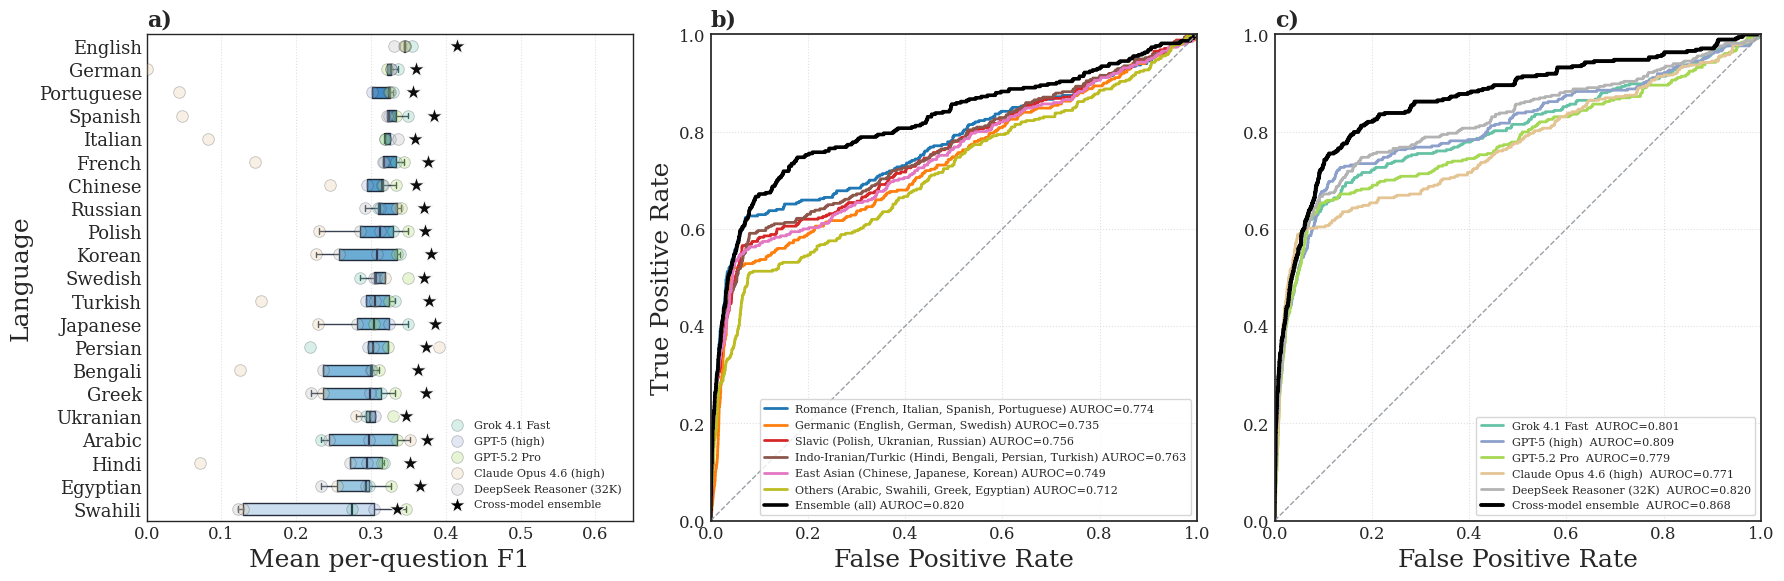

In [8]:
# Figure: RATA multilingual (prompt 2)

from pathlib import Path
import re
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config
PRED_COL = "answer_to_prompt_2"
KEY_COL = "SMILES_1"

MODEL_SOURCES = {
    "Grok 4.1 Fast": {
        "trans_dir": Path("../Results/results_grok_translations"),
        "trans_glob": "*_rata_100_*_gpt5*.csv",
        "english": Path("../Results/results_reasoning_budget/Grok_4_1_fast_OI_Benchmark.csv"),
    },
    "GPT-5 (high)": {
        "trans_dir": Path("../Results/results_GPT5_high_translations"),
        "trans_glob": "*_rata_100_*_gpt5*.csv",
        "english": Path("../Results/results_reasoning_budget/GPT_5_high_OI_Benchmark.csv"),
    },
    "GPT-5.2 Pro": {
        "trans_dir": Path("../Results/results_GPT5.2_pro_translations"),
        "trans_glob": "*_rata_100_*_gpt5*.csv",
        "english": Path("../Results/results_reasoning_budget/GPT_5.2_pro_OI_Benchmark.csv"),
    },
    "Claude Opus 4.6 (high)": {
        "trans_dir": Path("../Results/results_claude_opus_4.6_translations"),
        "trans_glob": "*_rata_100_*_gpt5*.csv",
        "english": Path("../Results/results_reasoning_budget/Claude_opus_4.6_high_OI_Benchmark.csv"),
    },
    "DeepSeek Reasoner (32K)": {
        "trans_dir": Path("../Results/results_deepseek_reasoner_32K_translations"),
        "trans_glob": "*_rata_100_*_gpt5*.csv",
        "english": Path("../Results/results_reasoning_budget/Deepseek_32K_OI_Benchmark.csv"),
    },
}

GROUPS = {
    "Romance": ["French", "Italian", "Spanish", "Portuguese"],
    "Germanic": ["English", "German", "Swedish"],
    "Slavic": ["Polish", "Ukranian", "Russian"],
    "Indo-Iranian/Turkic": ["Hindi", "Bengali", "Persian", "Turkish"],
    "East Asian": ["Chinese", "Japanese", "Korean"],
    "Others": ["Arabic", "Swahili", "Greek", "Egyptian"],
}

SOTA = {
    "mixture_similarity": 0.57,
    "odor_intensity": 0.78,
    "odor_pleasantness": 0.71,
}

# Helpers
_SPLIT_RE = re.compile(r"[;\n\r\t]+|(?<!\d),(?!\d)")
_NUMERIC_RE = re.compile(r"^[-+]?\d+(?:\.\d+)?$")


def normalize_token(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[\"'\[\]{}()<>.,:;!?%]+", "", s)
    s = re.sub(r"\s+", " ", s)
    return s


def split_items(cell: object) -> List[str]:
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [normalize_token(p) for p in parts if normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    return cleaned


def split_options(cell: object) -> List[str]:
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [normalize_token(p) for p in parts if normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    return cleaned


def language_from_filename(name: str) -> str:
    stem = Path(name).stem
    part = stem.split("_rata_100_", 1)[-1]
    part = re.sub(r"(_gpt\d+(?:\.\d+)?(?:_v\d+)?)$", "", part, flags=re.I)
    part = re.sub(r"(_v\d+)$", "", part, flags=re.I)
    lang = part.replace("_", " ").strip()
    if lang == "Mandarin Chinese":
        return "Chinese"
    return lang


def roc_curve_from_scores(
    y_true: np.ndarray, y_score: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, float]:
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]
    P = (y_true == 1).sum()
    N = (y_true == 0).sum()
    if P == 0 or N == 0:
        return np.array([]), np.array([]), float("nan")
    tps = np.cumsum(y_true == 1)
    fps = np.cumsum(y_true == 0)
    tpr = tps / P
    fpr = fps / N
    fpr = np.concatenate([[0.0], fpr, [1.0]])
    tpr = np.concatenate([[0.0], tpr, [1.0]])
    auc = float(np.trapz(tpr, fpr))
    return fpr, tpr, auc


# F1
def multilabel_f1(truth: set, pred: set) -> float:
    """Example-wise multilabel F1 between two label sets."""
    if not truth and not pred:
        return 1.0
    tp = len(truth & pred)
    if tp == 0:
        return 0.0
    fp = len(pred - truth)
    fn = len(truth - pred)
    return (2.0 * tp) / (2.0 * tp + fp + fn)


# Data

def load_model_lang_dfs(src: dict) -> Dict[str, pd.DataFrame]:
    """Load all translation CSVs + English for one model. Returns {lang: df}."""
    dfs: Dict[str, pd.DataFrame] = {}
    trans_dir: Path = src["trans_dir"]
    for fp in sorted(trans_dir.glob(src["trans_glob"])):
        lang = language_from_filename(fp.name)
        df = pd.read_csv(fp, dtype=str, keep_default_na=True)
        df = df[df["question_category"].astype(str).str.strip().str.lower() == "rata"].copy()
        if KEY_COL in df.columns:
            df = df[df[KEY_COL].astype(str).str.strip() != ""]
        if not df.empty:
            dfs[lang] = df
    # English
    eng_fp: Path = src["english"]
    if eng_fp.exists():
        df_eng = pd.read_csv(eng_fp, dtype=str, keep_default_na=True)
        df_eng = df_eng[
            df_eng["question_category"].astype(str).str.strip().str.lower() == "rata"
        ].copy()
        if KEY_COL in df_eng.columns:
            df_eng = df_eng[df_eng[KEY_COL].astype(str).str.strip() != ""]
        if not df_eng.empty:
            dfs["English"] = df_eng
    return dfs


# Load all models
all_model_lang_dfs: Dict[str, Dict[str, pd.DataFrame]] = {}
for model_name, src in MODEL_SOURCES.items():
    dfs = load_model_lang_dfs(src)
    if dfs:
        all_model_lang_dfs[model_name] = dfs
        print(f"  {model_name}: {len(dfs)} languages loaded")

if not all_model_lang_dfs:
    print("No RATA data found for any model.")
    raise SystemExit(0)

# Panel A data
model_lang_rows = []
for model_name, model_lang_dfs in all_model_lang_dfs.items():
    for lang, df in model_lang_dfs.items():
        f1s = []
        for _, row in df.iterrows():
            truth = set(split_items(row.get("answer", "")))
            pred = set(split_items(row.get(PRED_COL, "")))
            f1s.append(multilabel_f1(truth, pred))
        if f1s:
            model_lang_rows.append(
                {
                    "model": model_name,
                    "language": lang,
                    "f1": float(np.mean(f1s)),
                    "n": int(len(f1s)),
                }
            )

f1_model_lang = pd.DataFrame(model_lang_rows)


def cross_model_ensemble_f1_for_language(
    language: str, thresh: float = 0.5
) -> tuple[float, int] | None:
    """
    Cross-model ensemble for one language via per-option majority vote (>= thresh).
    Returns (mean per-question F1, n_questions) or None.
    """
    dfs_by_model = {
        model_name: model_lang_dfs[language]
        for model_name, model_lang_dfs in all_model_lang_dfs.items()
        if language in model_lang_dfs
    }
    if not dfs_by_model:
        return None

    keys = None
    for df in dfs_by_model.values():
        s = set(df[KEY_COL].astype(str))
        keys = s if keys is None else (keys & s)
    keys = sorted(keys) if keys else []
    if not keys:
        return None

    dfs_idx: Dict[str, pd.DataFrame] = {}
    for model_name, df in dfs_by_model.items():
        dfi = df.copy()
        dfi[KEY_COL] = dfi[KEY_COL].astype(str)
        dfs_idx[model_name] = dfi.set_index(KEY_COL, drop=False)

    base_df = next(iter(dfs_idx.values()))
    f1s = []
    for k in keys:
        if k not in base_df.index:
            continue
        row0 = base_df.loc[k]
        opts0 = split_options(row0.get("OPTIONS", ""))
        if not opts0:
            continue
        truth = set(split_items(row0.get("answer", "")))
        truth_idx = {i for i, opt in enumerate(opts0) if opt in truth}

        counts = [0] * len(opts0)
        voters = 0
        for _, dfi in dfs_idx.items():
            if k not in dfi.index:
                continue
            row = dfi.loc[k]
            opts = split_options(row.get("OPTIONS", ""))
            if len(opts) != len(opts0):
                continue
            pred = set(split_items(row.get(PRED_COL, "")))
            for i, opt in enumerate(opts):
                if opt in pred:
                    counts[i] += 1
            voters += 1
        if voters == 0:
            continue

        pred_idx = {i for i, c in enumerate(counts) if (c / voters) >= thresh}
        f1s.append(multilabel_f1(truth_idx, pred_idx))

    if not f1s:
        return None
    return float(np.mean(f1s)), int(len(f1s))


ensemble_rows = []
if not f1_model_lang.empty:
    for lang in sorted(f1_model_lang["language"].unique()):
        res = cross_model_ensemble_f1_for_language(lang)
        if res is None:
            continue
        f1_ens, n_ens = res
        ensemble_rows.append({"language": lang, "f1": f1_ens, "n": n_ens})

f1_ensemble_lang = pd.DataFrame(ensemble_rows)

lang_medians_plot = (
    f1_model_lang.groupby("language")["f1"].median() if not f1_model_lang.empty else pd.Series(dtype=float)
)
lang_order_plot = (
    list(lang_medians_plot.sort_values(ascending=False).index) if not lang_medians_plot.empty else []
)
f1_model_lang_plot = f1_model_lang


# ROC

def compute_group_curve(
    lang_list: List[str], lang_dfs: Dict[str, pd.DataFrame]
) -> dict | None:
    """
    Compute ROC from vote-fraction scores across the given languages.
    Returns dict with fpr, tpr, roc_auc (or None if insufficient data).
    """
    dfs = {lang: lang_dfs[lang] for lang in lang_list if lang in lang_dfs}
    if not dfs:
        return None

    # Intersection of SMILES_1 keys
    keys = None
    for df in dfs.values():
        s = set(df[KEY_COL].astype(str))
        keys = s if keys is None else (keys & s)
    keys = sorted(keys) if keys else []
    if not keys:
        return None

    base_df = next(iter(dfs.values()))
    base_df = base_df[base_df[KEY_COL].astype(str).isin(keys)]

    options_map: Dict[str, List[str]] = {}
    truth_idx_map: Dict[str, set] = {}
    for _, row in base_df.iterrows():
        k = str(row[KEY_COL])
        opts = split_options(row.get("OPTIONS", ""))
        options_map[k] = opts
        truth = set(split_items(row.get("answer", "")))
        truth_idx_map[k] = {i for i, opt in enumerate(opts) if opt in truth}

    lang_count = len(dfs)
    y_true_micro: List[int] = []
    y_score_micro: List[float] = []

    for _, row in base_df.iterrows():
        k = str(row[KEY_COL])
        opts = options_map.get(k, [])
        if not opts:
            continue
        truth_idx = truth_idx_map.get(k, set())
        counts = {i: 0 for i in range(len(opts))}
        for _lang, df in dfs.items():
            row_l = df[df[KEY_COL].astype(str) == k]
            if row_l.empty:
                continue
            row_l = row_l.iloc[0]
            opts_l = split_options(row_l.get("OPTIONS", ""))
            if len(opts_l) != len(opts):
                continue
            pred = set(split_items(row_l.get(PRED_COL, "")))
            for i, opt in enumerate(opts_l):
                if opt in pred:
                    counts[i] += 1
        for i in range(len(opts)):
            y_true_micro.append(1 if i in truth_idx else 0)
            y_score_micro.append(counts[i] / lang_count if lang_count > 0 else 0.0)

    y_true = np.asarray(y_true_micro, int)
    y_score = np.asarray(y_score_micro, float)
    fpr, tpr, auc_roc = roc_curve_from_scores(y_true, y_score)
    return {"fpr": fpr, "tpr": tpr, "roc_auc": auc_roc}


def compute_cross_model_ensemble_curve(
    all_model_lang_dfs: Dict[str, Dict[str, pd.DataFrame]]
) -> dict | None:
    """
    Pool ALL models x ALL languages into a single vote-fraction ROC.
    Each (model, language) pair is one voter.
    """
    # Collect every (model, lang) DataFrame
    combined: Dict[str, pd.DataFrame] = {}
    for model_name, model_dfs in all_model_lang_dfs.items():
        for lang, df in model_dfs.items():
            combined[f"{model_name}::{lang}"] = df
    if not combined:
        return None

    # Intersection of SMILES_1 keys
    keys = None
    for df in combined.values():
        s = set(df[KEY_COL].astype(str))
        keys = s if keys is None else (keys & s)
    keys = sorted(keys) if keys else []
    if not keys:
        return None

    base_df = next(iter(combined.values()))
    base_df = base_df[base_df[KEY_COL].astype(str).isin(keys)]

    options_map: Dict[str, List[str]] = {}
    truth_idx_map: Dict[str, set] = {}
    for _, row in base_df.iterrows():
        k = str(row[KEY_COL])
        opts = split_options(row.get("OPTIONS", ""))
        options_map[k] = opts
        truth = set(split_items(row.get("answer", "")))
        truth_idx_map[k] = {i for i, opt in enumerate(opts) if opt in truth}

    total_voters = len(combined)
    y_true_micro: List[int] = []
    y_score_micro: List[float] = []

    for _, row in base_df.iterrows():
        k = str(row[KEY_COL])
        opts = options_map.get(k, [])
        if not opts:
            continue
        truth_idx = truth_idx_map.get(k, set())
        counts = {i: 0 for i in range(len(opts))}
        for _tag, df in combined.items():
            row_l = df[df[KEY_COL].astype(str) == k]
            if row_l.empty:
                continue
            row_l = row_l.iloc[0]
            opts_l = split_options(row_l.get("OPTIONS", ""))
            if len(opts_l) != len(opts):
                continue
            pred = set(split_items(row_l.get(PRED_COL, "")))
            for i, opt in enumerate(opts_l):
                if opt in pred:
                    counts[i] += 1
        for i in range(len(opts)):
            y_true_micro.append(1 if i in truth_idx else 0)
            y_score_micro.append(counts[i] / total_voters if total_voters > 0 else 0.0)

    y_true = np.asarray(y_true_micro, int)
    y_score = np.asarray(y_score_micro, float)
    fpr, tpr, auc_roc = roc_curve_from_scores(y_true, y_score)
    return {"fpr": fpr, "tpr": tpr, "roc_auc": auc_roc}


# Panel B data
deepseek_dfs = all_model_lang_dfs.get("DeepSeek Reasoner (32K)", {})

group_curves_a: Dict[str, dict] = {}
for gname, langs in GROUPS.items():
    curve = compute_group_curve(langs, deepseek_dfs)
    if curve is not None:
        group_curves_a[gname] = curve

ensemble_a = compute_group_curve(list(deepseek_dfs.keys()), deepseek_dfs)


# Panel C data
model_curves_b: Dict[str, dict] = {}
for model_name, model_dfs in all_model_lang_dfs.items():
    curve = compute_group_curve(list(model_dfs.keys()), model_dfs)
    if curve is not None:
        model_curves_b[model_name] = curve

cross_model_curve = compute_cross_model_ensemble_curve(all_model_lang_dfs)


# Plot
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

fig, (ax_a, ax_b, ax_c) = plt.subplots(
    1,
    3,
    figsize=(18, 7.0),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.0]},
)

# Shared model colors (Panels A and C)
model_names_order = list(model_curves_b.keys())
model_colors = plt.cm.Set2(np.linspace(0, 1, max(3, len(model_names_order))))
model_cmap = dict(zip(model_names_order, model_colors))

# Panel A
if (not f1_model_lang_plot.empty) and lang_order_plot and (not lang_medians_plot.empty):
    data = [
        f1_model_lang_plot.loc[f1_model_lang_plot["language"] == lang, "f1"].to_numpy()
        for lang in lang_order_plot
    ]
    med = lang_medians_plot.reindex(lang_order_plot).to_numpy()
    vmin = float(np.nanmin(med))
    vmax = float(np.nanmax(med))
    if vmax <= vmin:
        vmax = vmin + 1e-9

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.Blues
    box_colors = cmap(0.25 + 0.65 * norm(med))

    bp = ax_a.boxplot(
        data,
        vert=False,
        patch_artist=True,
        widths=0.48,
        showfliers=False,
        medianprops={"color": "#111827", "linewidth": 1.6},
        boxprops={"edgecolor": "#111827", "linewidth": 1.0},
        whiskerprops={"color": "#374151", "linewidth": 1.0},
        capprops={"color": "#374151", "linewidth": 1.0},
    )
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)

    # Overlay per-model points (bubble plot) + cross-model ensemble (black star)
    f1_pivot = f1_model_lang_plot.pivot(index="language", columns="model", values="f1")
    ensemble_map = (
        dict(zip(f1_ensemble_lang["language"], f1_ensemble_lang["f1"]))
        if not f1_ensemble_lang.empty
        else {}
    )

    ax_a.set_yticks(range(1, len(lang_order_plot) + 1))
    ax_a.set_yticklabels(lang_order_plot, fontsize=13)
    ax_a.invert_yaxis()
    ax_a.set_xlim(0, 0.65)
    ax_a.set_xlabel("Mean per-question F1", fontsize=18)
    ax_a.set_ylabel("Language", fontsize=18)
    ax_a.grid(True, axis="x", linestyle=":", linewidth=0.8, alpha=0.6)
    ax_a.set_box_aspect(1)
    for spine in ax_a.spines.values():
        spine.set_linewidth(1.0)

    for yi, lang in enumerate(lang_order_plot, start=1):
        for model_name in model_names_order:
            if model_name not in f1_pivot.columns or lang not in f1_pivot.index:
                continue
            val = float(f1_pivot.loc[lang, model_name])
            if not np.isfinite(val):
                continue
            ax_a.scatter(
                val,
                yi,
                s=70,
                color=model_cmap.get(model_name, "#6b7280"),
                edgecolors="#111827",
                linewidth=0.6,
                alpha=0.25,
                zorder=4,
            )

        ens = ensemble_map.get(lang)
        if ens is not None and np.isfinite(float(ens)):
            ax_a.scatter(
                float(ens),
                yi,
                marker="*",
                s=160,
                color="black",
                edgecolors="white",
                linewidth=0.8,
                alpha=0.95,
                zorder=5,
            )

    # Legend (models + cross-model ensemble)
    legend_handles = []
    for model_name in model_names_order:
        legend_handles.append(
            ax_a.scatter(
                [],
                [],
                s=70,
                color=model_cmap.get(model_name, "#6b7280"),
                edgecolors="#111827",
                linewidth=0.6,
                alpha=0.25,
                label=model_name,
            )
        )
    legend_handles.append(
        ax_a.scatter(
            [],
            [],
            marker="*",
            s=160,
            color="black",
            edgecolors="white",
            linewidth=0.8,
            label="Cross-model ensemble",
        )
    )
    ax_a.legend(
        handles=legend_handles,
        loc="lower right",
        ncol=1,
        frameon=False,
        fontsize=8,
        handletextpad=0.5,
        columnspacing=1.2,
        borderaxespad=0.6,
    )
else:
    ax_a.axis("off")

ax_a.set_title("a)", fontsize=16, fontweight="bold", loc="left")

# Panel B
family_colors = plt.cm.tab10(np.linspace(0, 1, max(3, len(group_curves_a) + 1)))
family_cmap = dict(zip(list(group_curves_a.keys()) + ["Ensemble"], family_colors))
SEP = ", "
family_labels = {
    g: f"{g} ({SEP.join([l for l in GROUPS[g] if l in deepseek_dfs])})"
    for g in group_curves_a
}

for gname, data in group_curves_a.items():
    ax_b.plot(
        data["fpr"], data["tpr"],
        color=family_cmap[gname], linewidth=2.0,
        label=f"{family_labels[gname]} AUROC={data['roc_auc']:.3f}",
    )

if ensemble_a is not None:
    ax_b.plot(
        ensemble_a["fpr"], ensemble_a["tpr"],
        color="black", linewidth=2.6,
        label=f"Ensemble (all) AUROC={ensemble_a['roc_auc']:.3f}",
    )

ax_b.plot([0, 1], [0, 1], linestyle="--", color="#9aa0a6", linewidth=1.0)
ax_b.set_xlabel("False Positive Rate", fontsize=18)
ax_b.set_ylabel("True Positive Rate", fontsize=18)
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 1)
ax_b.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
ax_b.legend(frameon=True, loc="lower right", fontsize=8, ncol=1)
ax_b.set_title("b)", fontsize=16, fontweight="bold", loc="left")
ax_b.set_box_aspect(1)

# Panel C
for model_name, data in model_curves_b.items():
    ax_c.plot(
        data["fpr"], data["tpr"],
        color=model_cmap[model_name], linewidth=2.0,
        label=f"{model_name}  AUROC={data['roc_auc']:.3f}",
    )

if cross_model_curve is not None:
    ax_c.plot(
        cross_model_curve["fpr"], cross_model_curve["tpr"],
        color="black", linewidth=2.8, linestyle="-",
        label=f"Cross-model ensemble  AUROC={cross_model_curve['roc_auc']:.3f}",
    )

ax_c.plot([0, 1], [0, 1], linestyle="--", color="#9aa0a6", linewidth=1.0)
ax_c.set_xlabel("False Positive Rate", fontsize=18)
ax_c.set_xlim(0, 1)
ax_c.set_ylim(0, 1)
ax_c.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
ax_c.legend(frameon=True, loc="lower right", fontsize=8, ncol=1)
ax_c.set_title("c)", fontsize=16, fontweight="bold", loc="left")
ax_c.set_box_aspect(1)

# Tight layout first, then force equal top/bottom alignment across panels
fig.tight_layout()
_pos_a, _pos_b, _pos_c = ax_a.get_position(), ax_b.get_position(), ax_c.get_position()
_y0 = min(_pos_a.y0, _pos_b.y0, _pos_c.y0)
_y1 = max(_pos_a.y1, _pos_b.y1, _pos_c.y1)
for _ax in (ax_a, ax_b, ax_c):
    _p = _ax.get_position()
    _ax.set_position([_p.x0, _y0, _p.width, _y1 - _y0])

fig.savefig("Figure_5.pdf", bbox_inches="tight")
plt.show()


In [7]:
# Table: benchmark results (prompt 2)

from pathlib import Path
import re
import numpy as np
import pandas as pd

# Config
DATA_DIR = Path("../Results/results_reasoning_budget")
PATTERN = "*_OI_Benchmark.csv"
PRED_COL = "answer_to_prompt_2"  # compound name prompt

CAT_ORDER = [
    "odor_classification",
    "primary_odor_descriptor",
    "odor_intensity",
    "odor_pleasantness",
    "rata",
    "mixture_similarity",
    "or_activation",
    "smell_identification",
]
CAT_LABELS = {
    "odor_classification": "OC",
    "primary_odor_descriptor": "POD",
    "odor_intensity": "OI",
    "odor_pleasantness": "OP",
    "rata": "RATA",
    "mixture_similarity": "OS",
    "or_activation": "ORA",
    "smell_identification": "SIT",
}
WEIGHTS = {
    "odor_classification": 175,
    "primary_odor_descriptor": 175,
    "odor_intensity": 175,
    "odor_pleasantness": 175,
    "rata": 100,
    "mixture_similarity": 100,
    "or_activation": 80,
    "smell_identification": 30,
}
MULTIANSWER_CATS = {"rata", "or_activation"}

# Helpers
_SPLIT_RE = re.compile(r"[;\n\r\t]+|(?<!\d),(?!\d)")
_NUMERIC_RE = re.compile(r"^[-+]?\d+(?:\.\d+)?$")

def normalize_token(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[\"'\[\]{}()<>.,:;!?%]+", "", s)
    s = re.sub(r"\s+", " ", s)
    return s

def split_items(cell: object):
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    text = str(cell).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return []
    parts = [p for p in _SPLIT_RE.split(text) if p is not None]
    cleaned = [normalize_token(p) for p in parts if normalize_token(p)]
    cleaned = [t for t in cleaned if not _NUMERIC_RE.fullmatch(t)]
    return cleaned

def model_name_from_path(p: Path) -> str:
    name = p.name
    suf = "_OI_Benchmark.csv"
    if name.endswith(suf):
        return name[: -len(suf)]
    return name.removesuffix(".csv")

def parse_model_reasoning(base: str):
    # Returns (Model, Reasoning)
    m = base.lower()
    if m.startswith("gemini"):
        mm = re.search(r"(\d{4,6})", base)
        return "Gemini 2.5 Pro", mm.group(1) if mm else "default"
    if m.startswith("grok_3_mini"):
        return "Grok 3 Mini", base.split("_")[-1]
    if m.startswith("grok_4") or m.startswith("grok4"):
        return "Grok 4.1 Fast", "default"
    if m.startswith("claude_opus_4.6"):
        parts = base.split("_")
        suffix = parts[-1] if len(parts) > 3 else "\u2014"
        return "Claude Opus 4.6", suffix
    if m.startswith("claude_opus_4.5"):
        return "Claude Opus 4.5", "\u2014"
    if m.startswith("claude_sonnet"):
        return "Claude Sonnet 4.5", "\u2014"
    if m.startswith("deepseek"):
        mm = re.search(r"(\d+k)", base, re.IGNORECASE)
        return "DeepSeek Reasoner", mm.group(0).upper() if mm else "\u2014"
    if m.startswith("gpt_5.2") or m.startswith("gpt-5.2"):
        return "GPT-5.2 Pro", "default"
    if m.startswith("gpt_5_pro") or m.startswith("gpt-5-pro"):
        return "GPT-5 Pro", "default"
    if re.match(r"gpt[_\-]?5", m):
        if "low" in m: return "GPT-5", "low"
        if "high" in m: return "GPT-5", "high"
        return "GPT-5", "default"
    if "oss" in m:
        mm = re.search(r"(\d+b)", m, re.IGNORECASE)
        return "GPT-OSS", mm.group(0).upper() if mm else "\u2014"
    if m.startswith("o3"):
        return "o3", base.split("_")[-1]
    if m.startswith("o4"):
        return ("o4-mini" if "mini" in base else "o4"), base.split("_")[-1]
    if m.startswith("llama"):
        return "Llama 3.3 70B", "\u2014"
    # fallback
    return base.replace("_", " "), "\u2014"

def family_from_model(model: str) -> str:
    m = model.lower()
    if m.startswith("gpt") or m.startswith("o3") or m.startswith("o4"):
        return "openai"
    if m.startswith("claude"):
        return "claude"
    if m.startswith("gemini"):
        return "gemini"
    if m.startswith("grok"):
        return "grok"
    if m.startswith("deepseek") or m.startswith("llama"):
        return "open_source"
    return "other"

def score_row(cat: str, truth: set, pred: set) -> float:
    if cat in MULTIANSWER_CATS:
        tp = len(truth & pred)
        fp = len(pred - truth)
        fn = len(truth - pred)
        if tp == 0:
            return 0.0
        return (2.0 * tp) / (2.0 * tp + fp + fn)
    # any-overlap accuracy
    return 1.0 if len(truth & pred) > 0 else 0.0

# Score
files = sorted(DATA_DIR.glob(PATTERN))
if not files:
    print(f"No files found in {DATA_DIR}")
    raise SystemExit(0)

records = []
for fp in files:
    try:
        df = pd.read_csv(fp, dtype=str, keep_default_na=True)
    except Exception:
        continue
    if PRED_COL not in df.columns or "answer" not in df.columns or "question_category" not in df.columns:
        continue

    base = model_name_from_path(fp)
    model, reasoning = parse_model_reasoning(base)
    family = family_from_model(model)

    # normalize category
    df["_cat"] = df["question_category"].astype(str).str.strip().str.lower()

    cat_scores = {}
    for cat in CAT_ORDER:
        sub = df[df["_cat"] == cat].copy()
        if sub.empty:
            cat_scores[cat] = np.nan
            continue
        scores = []
        for _, row in sub.iterrows():
            truth = set(split_items(row.get("answer", "")))
            pred = set(split_items(row.get(PRED_COL, "")))
            scores.append(score_row(cat, truth, pred))
        cat_scores[cat] = 100.0 * float(np.mean(scores)) if scores else np.nan

    # unweighted overall across tasks (mean of per-task scores)
    vals = [cat_scores.get(cat, np.nan) for cat in WEIGHTS.keys()]
    vals = [v for v in vals if np.isfinite(v)]
    overall = float(np.mean(vals)) if vals else np.nan

    row = {
        "Model": model,
        "Reasoning": reasoning,
        "Family": family,
        **{CAT_LABELS[k]: cat_scores[k] for k in CAT_ORDER},
        "Overall": overall,
    }
    records.append(row)

res = pd.DataFrame(records)

# order rows (closed-source then open-source)
family_order = ["openai", "gemini", "grok", "claude", "other"]
closed = res[res["Family"] != "open_source"].copy()
open_src = res[res["Family"] == "open_source"].copy()

closed["Family"] = pd.Categorical(closed["Family"], categories=family_order, ordered=True)
closed = closed.sort_values(["Family", "Model", "Reasoning"]).reset_index(drop=True)
open_src = open_src.sort_values(["Model", "Reasoning"]).reset_index(drop=True)

# compute best and second-best per column
cols = ["OC", "POD", "OI", "OP", "RATA", "OS", "ORA", "SIT", "Overall"]
col_best = {}
col_second = {}
for c in cols:
    vals = res[c].dropna().values
    if len(vals) == 0:
        col_best[c] = col_second[c] = None
        continue
    uniq = sorted(set(np.round(vals, 6)), reverse=True)
    col_best[c] = uniq[0] if uniq else None
    col_second[c] = uniq[1] if len(uniq) > 1 else None

def fmt_val(v, col):
    if not np.isfinite(v):
        return "—"
    v_rounded = round(float(v), 1)
    if col_best[col] is not None and abs(v - col_best[col]) < 1e-6:
        return rf"\textbf{{{v_rounded:.1f}}}"
    if col_second[col] is not None and abs(v - col_second[col]) < 1e-6:
        return rf"\underline{{{v_rounded:.1f}}}"
    return f"{v_rounded:.1f}"

# LaTeX
def row_to_latex(r):
    parts = [
        r["Model"],
        r["Reasoning"],
        fmt_val(r["OC"], "OC"),
        fmt_val(r["POD"], "POD"),
        fmt_val(r["OI"], "OI"),
        fmt_val(r["OP"], "OP"),
        fmt_val(r["RATA"], "RATA"),
        fmt_val(r["OS"], "OS"),
        fmt_val(r["ORA"], "ORA"),
        fmt_val(r["SIT"], "SIT"),
        fmt_val(r["Overall"], "Overall"),
    ]
    return " & ".join(parts) + " \\\\"

lines = []
lines.append(r"\begin{table*}[htbp]")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\caption{Olfactory Intelligence (OI) Benchmark results using compound name prompts. Accuracy (\%) is reported per task and overall (unweighted mean across tasks). Abbreviations: \textbf{OC} = Odor Classification ($n$=175), \textbf{POD} = Primary Odor Descriptor ($n$=175), \textbf{OI} = Odor Intensity ($n$=175), \textbf{OP} = Odor Pleasantness ($n$=175), \textbf{RATA} = Rate-All-That-Apply ($n$=100), \textbf{OS} = Odor Similarity ($n$=100), \textbf{ORA} = Olfactory Receptor Activation ($n$=80), \textbf{SIT} = Smell Identification Test ($n$=30). \textbf{Bold} = best overall; \underline{underlined} = second best.}")
lines.append(r"\label{tab:oi_results}")
lines.append(r"\begin{tabular}{@{}ll|cccc|cc|cc|c@{}}")
lines.append(r"\toprule")
lines.append(r"& & \multicolumn{4}{c|}{\textbf{Simple} ($N$=700)} & \multicolumn{2}{c|}{\textbf{Intermediate} ($N$=200)} & \multicolumn{2}{c|}{\textbf{Hard} ($N$=110)} & \\")
lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-8} \cmidrule(lr){9-10}")
lines.append(r"\textbf{Model} & \textbf{Reasoning} & OC & POD & OI & OP & RATA & OS & ORA & SIT & \textbf{Overall} \\")
lines.append(r"\midrule")
lines.append(r"\multicolumn{11}{c}{\cellcolor[HTML]{FFF3CA}\textbf{Closed-Source}} \\")
lines.append(r"\midrule")

for _, r in closed.iterrows():
    lines.append(row_to_latex(r))

lines.append(r"\midrule")
lines.append(r"\multicolumn{11}{c}{\cellcolor[HTML]{D9E1F4}\textbf{Open-Source}} \\")
lines.append(r"\midrule")

for _, r in open_src.iterrows():
    lines.append(row_to_latex(r))

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table*}")

print("\n".join(lines))


\begin{table*}[htbp]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{Olfactory Intelligence (OI) Benchmark results using compound name prompts. Accuracy (\%) is reported per task and overall (unweighted mean across tasks). Abbreviations: \textbf{OC} = Odor Classification ($n$=175), \textbf{POD} = Primary Odor Descriptor ($n$=175), \textbf{OI} = Odor Intensity ($n$=175), \textbf{OP} = Odor Pleasantness ($n$=175), \textbf{RATA} = Rate-All-That-Apply ($n$=100), \textbf{OS} = Odor Similarity ($n$=100), \textbf{ORA} = Olfactory Receptor Activation ($n$=80), \textbf{SIT} = Smell Identification Test ($n$=30). \textbf{Bold} = best overall; \underline{underlined} = second best.}
\label{tab:oi_results}
\begin{tabular}{@{}ll|cccc|cc|cc|c@{}}
\toprule
& & \multicolumn{4}{c|}{\textbf{Simple} ($N$=700)} & \multicolumn{2}{c|}{\textbf{Intermediate} ($N$=200)} & \multicolumn{2}{c|}{\textbf{Hard} ($N$=110)} & \\
\cmidrule(lr){3-6} \cmidrule(lr){7-8} \cmidrule(lr){9-10}
\textbf{Model} & \textbf{Re